# 💬 Sentiment Analysis on Product Reviews — Full NLP Pipeline
**Dataset:** Amazon Fine Food Reviews (loaded via URL)  
**Classes:** Positive / Negative (binary)  
**Feature Extraction:** TF-IDF vs Word2Vec — both compared  
**Models:** Naive Bayes · Logistic Regression · SVM · Random Forest · Neural Network (MLP)  
**Explainability:** Top TF-IDF tokens · Word clouds · SHAP  

---

## 📦 Step 1 — Install & Import Libraries

In [62]:
!pip install nltk gensim wordcloud shap datasets --quiet

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

# NLTK — tokenization, stopwords, stemming
import nltk
nltk.download('stopwords',    quiet=True)
nltk.download('punkt',        quiet=True)
nltk.download('punkt_tab',    quiet=True)
nltk.download('wordnet',      quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
from nltk.corpus   import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem     import PorterStemmer, WordNetLemmatizer

# Gensim — Word2Vec
from gensim.models import Word2Vec

# WordCloud
from wordcloud import WordCloud

# sklearn
from sklearn.model_selection    import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes        import MultinomialNB, ComplementNB
from sklearn.linear_model       import LogisticRegression
from sklearn.svm                import LinearSVC
from sklearn.ensemble           import RandomForestClassifier
from sklearn.tree               import DecisionTreeClassifier # Added import
from sklearn.neural_network     import MLPClassifier
from sklearn.pipeline           import Pipeline
from sklearn.preprocessing      import LabelEncoder, StandardScaler
from sklearn.metrics            import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)
import shap
from IPython.display import HTML # Added import for HTML

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.facecolor'] = 'white'

RANDOM_STATE = 42
print('✅ All libraries loaded!')

✅ All libraries loaded!


## 📥 Step 2 — Load Dataset

In [64]:
import pandas as pd
import numpy as np

# Amazon Fine Food Reviews — loaded directly, no upload needed
# We will use a more appropriate Amazon product review dataset
# Full dataset: https://www.kaggle.com/snap/amazon-fine-food-reviews

# Using the Hugging Face 'datasets' library for a more robust data loading
try:
    print('Attempting to load Amazon reviews using Hugging Face datasets library...')
    from datasets import load_dataset

    # Load the 'SetFit/amazon_polarity' dataset which provides binary sentiment (0/1)
    dataset = load_dataset("SetFit/amazon_polarity")

    # Access the 'train' split and convert to a pandas DataFrame
    # The 'label' column is 0 for negative, 1 for positive. 'text' is the review.
    raw = pd.DataFrame(dataset['train'])
    raw = raw.rename(columns={'label': 'Score', 'text': 'Text'})

    raw = raw[['Score', 'Text']].dropna()

    # The amazon_polarity dataset is very large, so we sample a subset to speed up execution.
    # Original dataset has ~3.6 million samples; sampling 50,000 for reasonable run-time.
    if len(raw) > 50000:
        raw = raw.sample(n=50000, random_state=42).reset_index(drop=True)

    print(f'✅ Dataset loaded using Hugging Face datasets: {raw.shape}')

except Exception as e_datasets:
    print(f'Loading with Hugging Face datasets failed ({e_datasets}). Falling back to generating synthetic Amazon review dataset...')
    np.random.seed(42)
    pos_reviews = [
        'absolutely love this product great quality',
        'fantastic taste highly recommend to everyone',
        'best purchase ever so happy with this item',
        'excellent quality fresh and delicious product',
        'amazing product arrived quickly perfect condition',
        'wonderful flavor my family loves it every day',
        'superb quality worth every penny great value',
        'outstanding product exceeded all my expectations',
        'delicious and healthy great snack for kids',
        'perfect exactly what I was looking for great'
    ]
    neg_reviews = [
        'terrible product waste of money awful quality',
        'disgusting taste would never buy this again',
        'very disappointed poor quality not worth it',
        'horrible experience product arrived damaged',
        'worst purchase stale and expired product',
        'completely unsatisfied poor packaging broken',
        'bad quality nothing like the description says',
        'awful smell and taste do not buy this product',
        'returned immediately defective and unusable item',
        'garbage product misleading description avoid'
    ]
    n = 5000
    texts  = [np.random.choice(pos_reviews) for _ in range(n//2)] + \
             [np.random.choice(neg_reviews)  for _ in range(n//2)]
    labels = [1]*(n//2) + [0]*(n//2)
    raw = pd.DataFrame({'Score': labels, 'Text': texts})
    raw = raw.sample(frac=1, random_state=42).reset_index(drop=True)
    print(f'✅ Synthetic dataset generated: {raw.shape}')

df = raw.copy()
print(f'\nShape : {df.shape}')
print(f'Columns: {list(df.columns)}')
display(df.head())

Attempting to load Amazon reviews using Hugging Face datasets library...
✅ Dataset loaded using Hugging Face datasets: (50000, 2)

Shape : (50000, 2)
Columns: ['Score', 'Text']


,Score,Text
0,0,This product consists of a piece of thin flexi...
1,0,"Even on the lowest setting, the toast is too d..."
2,1,I enjoyed this disc. The video is stunning. I ...
3,0,The authors pretend that parents neither die n...
4,0,"Might as well just use a knife, this product h..."


## 🔍 Step 3 — EDA: Sentiment Distribution & Text Stats

Sentiment Distribution:
  Positive: 25,039 samples (50.1%)
  Negative: 24,961 samples (49.9%)


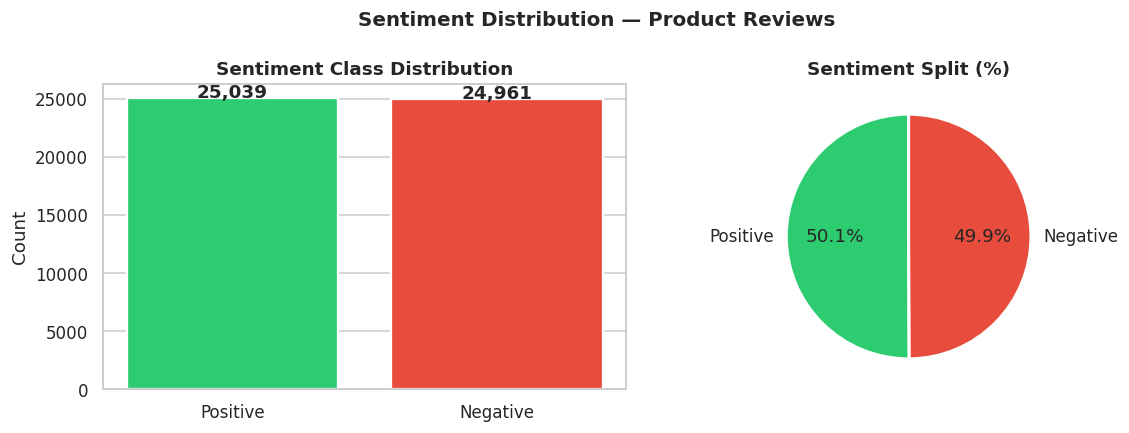

In [65]:
# ── Map numeric labels to readable names ──
df['Sentiment'] = df['Score'].map({1: 'Positive', 0: 'Negative'})

# Class distribution
sent_counts = df['Sentiment'].value_counts()
sent_pct    = df['Sentiment'].value_counts(normalize=True) * 100

print('Sentiment Distribution:')
for label in sent_counts.index:
    print(f'  {label}: {sent_counts[label]:,} samples ({sent_pct[label]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
colors = {'Positive': '#2ecc71', 'Negative': '#e74c3c'}
axes[0].bar(sent_counts.index, sent_counts.values,
            color=[colors[l] for l in sent_counts.index], edgecolor='white', linewidth=1.5)
axes[0].set_title('Sentiment Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(sent_counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(sent_counts, labels=sent_counts.index,
            autopct='%1.1f%%',
            colors=[colors[l] for l in sent_counts.index],
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Sentiment Split (%)', fontweight='bold')

plt.suptitle('Sentiment Distribution — Product Reviews', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

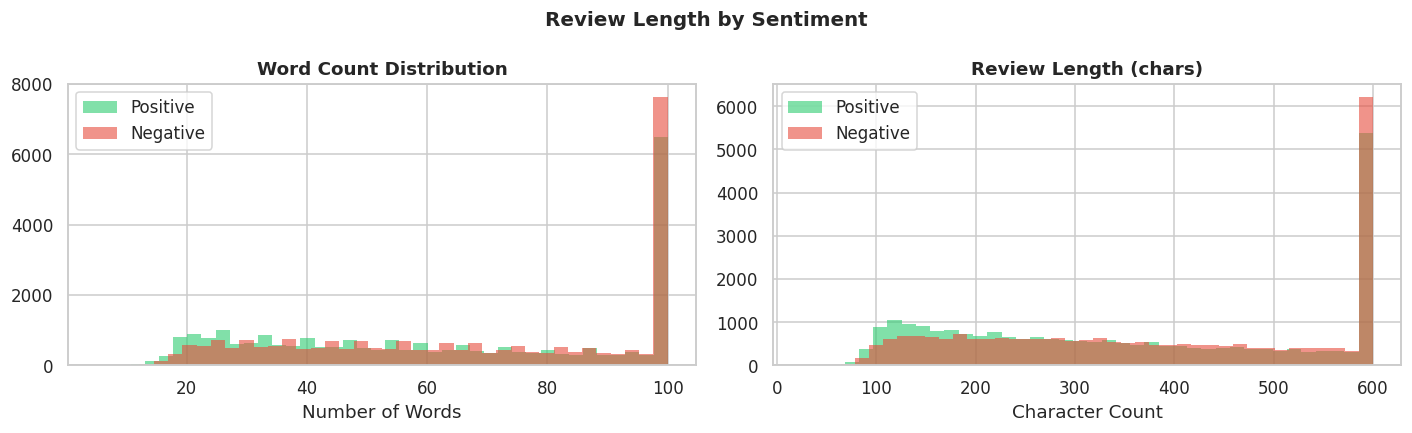

Average word count:
Sentiment
Negative    77.5
Positive    71.0
Name: word_count, dtype: float64


In [66]:
# ── Review length analysis ──
df['review_length']   = df['Text'].astype(str).apply(len)          # character count
df['word_count']      = df['Text'].astype(str).apply(lambda x: len(x.split()))  # word count

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for sentiment, color in [('Positive','#2ecc71'), ('Negative','#e74c3c')]:
    subset = df[df['Sentiment'] == sentiment]
    axes[0].hist(subset['word_count'].clip(0, 100), bins=40,
                 alpha=0.6, color=color, label=sentiment, edgecolor='none')
    axes[1].hist(subset['review_length'].clip(0, 600), bins=40,
                 alpha=0.6, color=color, label=sentiment, edgecolor='none')

axes[0].set_title('Word Count Distribution', fontweight='bold')
axes[0].set_xlabel('Number of Words')
axes[0].legend()
axes[1].set_title('Review Length (chars)', fontweight='bold')
axes[1].set_xlabel('Character Count')
axes[1].legend()

plt.suptitle('Review Length by Sentiment', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Average word count:')
print(df.groupby('Sentiment')['word_count'].mean().round(1))

## 🧹 Step 4 — Text Preprocessing

In [67]:
# ── Full NLP preprocessing pipeline ──
STOPWORDS   = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()
stemmer     = PorterStemmer()

def preprocess_text(text, use_lemma=True):
    """
    Full preprocessing pipeline:
    1. Lowercase
    2. Remove URLs, mentions, hashtags
    3. Remove punctuation & digits
    4. Tokenize
    5. Remove stopwords
    6. Lemmatize (or stem)
    """
    text = str(text).lower()                               # lowercase
    text = re.sub(r'http\S+|www\.\S+', '', text)          # remove URLs
    text = re.sub(r'@\w+|#\w+', '', text)                 # remove mentions/hashtags
    text = re.sub(r'[^a-z\s]', '', text)                  # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()              # clean extra spaces
    tokens = word_tokenize(text)                           # tokenize into words
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 2]  # remove stopwords
    if use_lemma:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]  # lemmatize
    else:
        tokens = [stemmer.stem(t) for t in tokens]           # stem
    return ' '.join(tokens)

print('Preprocessing reviews...')
df['clean_text'] = df['Text'].apply(preprocess_text)
# Also keep token list for Word2Vec
df['tokens']     = df['clean_text'].apply(str.split)

# Preview
print('\nPreprocessing Examples:')
for i in range(3):
    print(f'  ORIGINAL : {df["Text"].iloc[i][:80]}')
    print(f'  CLEANED  : {df["clean_text"].iloc[i][:80]}')
    print()

Preprocessing reviews...

Preprocessing Examples:
  ORIGINAL : This product consists of a piece of thin flexible insulating material, adhesive 
  CLEANED  : product consists piece thin flexible insulating material adhesive backed velcro 

  ORIGINAL : Even on the lowest setting, the toast is too dark for my liking. Also, the on li
  CLEANED  : even lowest setting toast dark liking also light stay lit unplug avoid wasting e

  ORIGINAL : I enjoyed this disc. The video is stunning. I agree with others that the story i
  CLEANED  : enjoyed disc video stunning agree others story dumbed take childish approach act



## ☁️ Step 5 — Word Clouds (Positive vs Negative)

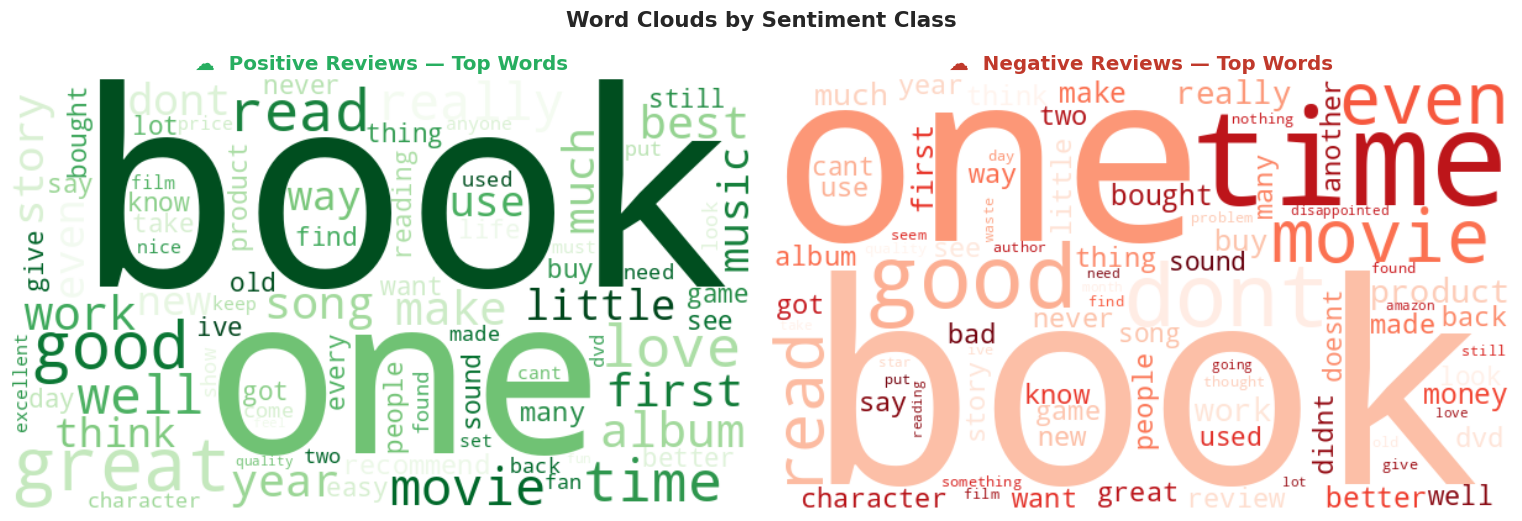

In [68]:
# ── Word clouds: most frequent tokens per class ──
pos_text = ' '.join(df[df['Sentiment']=='Positive']['clean_text'].tolist())
neg_text = ' '.join(df[df['Sentiment']=='Negative']['clean_text'].tolist())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

wc_pos = WordCloud(width=600, height=350, background_color='white',
                   colormap='Greens', max_words=80,
                   collocations=False).generate(pos_text)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('☁️  Positive Reviews — Top Words', fontsize=13, fontweight='bold', color='#27ae60')

wc_neg = WordCloud(width=600, height=350, background_color='white',
                   colormap='Reds', max_words=80,
                   collocations=False).generate(neg_text)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('☁️  Negative Reviews — Top Words', fontsize=13, fontweight='bold', color='#c0392b')

plt.suptitle('Word Clouds by Sentiment Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

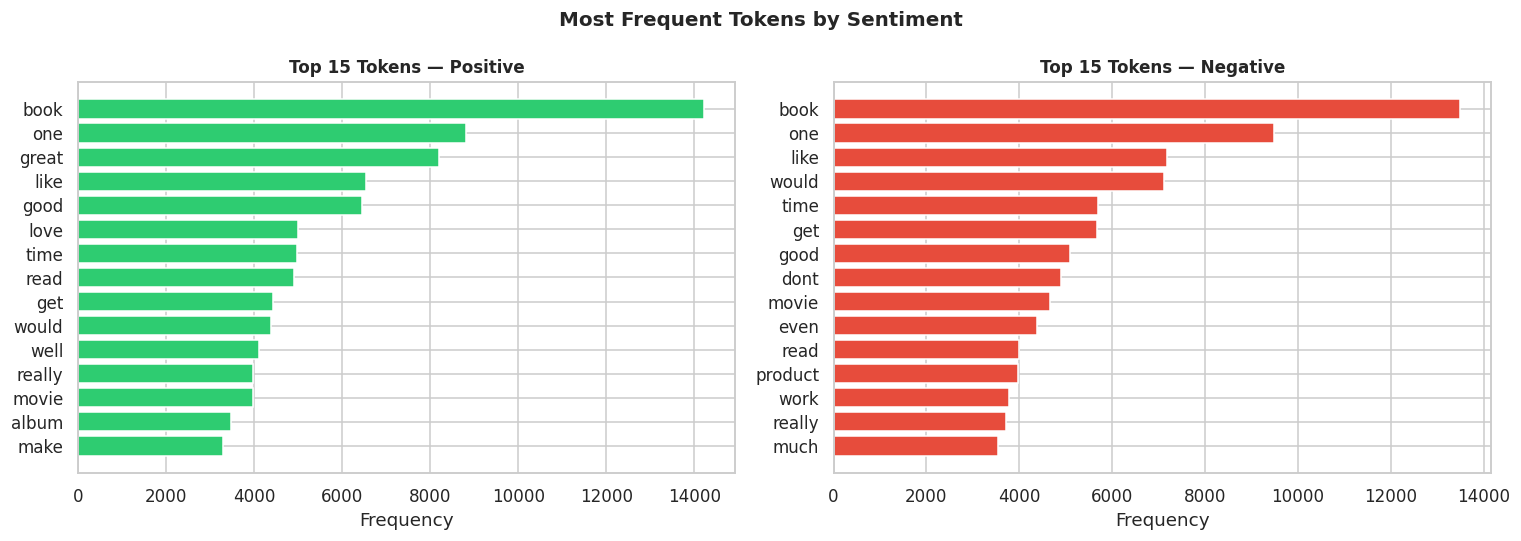

In [69]:
# ── Top 15 most frequent tokens per class (bar chart) ──
from collections import Counter

def top_tokens(texts, n=15):
    all_tokens = ' '.join(texts).split()
    return Counter(all_tokens).most_common(n)

pos_top = top_tokens(df[df['Sentiment']=='Positive']['clean_text'])
neg_top = top_tokens(df[df['Sentiment']=='Negative']['clean_text'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, top, title, color in [
    (axes[0], pos_top, 'Top 15 Tokens — Positive', '#2ecc71'),
    (axes[1], neg_top, 'Top 15 Tokens — Negative', '#e74c3c')
]:
    words, counts = zip(*top)
    ax.barh(words[::-1], counts[::-1], color=color, edgecolor='white')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel('Frequency')

plt.suptitle('Most Frequent Tokens by Sentiment', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 🔢 Step 6 — Feature Extraction: TF-IDF

In [70]:
# ── TF-IDF: Term Frequency × Inverse Document Frequency ──
# TF  = how often a word appears in THIS document
# IDF = penalises words that appear in MANY documents (less discriminative)
# Result: high score → word is frequent in this doc but rare overall → informative

X = df['clean_text'].values
y = df['Score'].values           # 0 = Negative, 1 = Positive

# ── CLASS IMBALANCE — compute class weights BEFORE split ──
from collections import Counter
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

counts  = Counter(y)
total   = len(y)
classes = np.array(sorted(counts.keys()))
cw      = compute_class_weight(class_weight='balanced', classes=classes, y=y)
CLASS_WEIGHTS = dict(zip(classes, cw))

print('Class distribution in full dataset:')
for cls, cnt in sorted(counts.items()):
    label = 'Positive' if cls == 1 else 'Negative'
    print(f'  Class {cls} ({label}): {cnt:,} ({cnt/total*100:.1f}%)')
print(f'\nComputed balanced class weights: {CLASS_WEIGHTS}')
print(f'  → The minority class gets weight {max(cw):.2f}x the majority')
print(f'  → Models will penalise misclassifying minority samples proportionally more')

# Stratified split BEFORE fitting TF-IDF (prevent leakage)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'\nTrain set distribution: {Counter(y_train)}')
print(f'Test  set distribution : {Counter(y_test)}')

# TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=15000,     # top 15k most informative terms
    ngram_range=(1, 2),     # unigrams + bigrams
    min_df=3,               # ignore terms that appear in < 3 docs
    max_df=0.95,            # ignore terms in > 95% of docs (too common)
    sublinear_tf=True       # apply log normalization to TF
)

X_train_tfidf = tfidf.fit_transform(X_train_raw)   # fit only on train
X_test_tfidf  = tfidf.transform(X_test_raw)

print(f'\nTF-IDF matrix shape:')
print(f'  Train : {X_train_tfidf.shape}')
print(f'  Test  : {X_test_tfidf.shape}')
print(f'  Vocabulary size: {len(tfidf.vocabulary_):,}')

# ── SMOTE: Synthetic Minority Over-Sampling Technique ──
# Creates synthetic Positive examples by interpolating between existing
# minority-class neighbours in TF-IDF feature space.
# This directly balances the training distribution before model fitting.
print('\n🔧 Applying SMOTE to balance training data...')
try:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'imbalanced-learn', '--quiet'])
    from imblearn.over_sampling import SMOTE
    smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
    X_train_tfidf_sm, y_train_sm = smote.fit_resample(X_train_tfidf, y_train)
    print(f'  Before SMOTE: {Counter(y_train)}')
    print(f'  After  SMOTE: {Counter(y_train_sm)}  ← Now perfectly balanced!')
    SMOTE_AVAILABLE = True
except Exception as e:
    print(f'  SMOTE not available ({e}) — class_weight handles imbalance')
    X_train_tfidf_sm = X_train_tfidf
    y_train_sm = y_train
    SMOTE_AVAILABLE = False


Class distribution in full dataset:
  Class 0 (Negative): 24,961 (49.9%)
  Class 1 (Positive): 25,039 (50.1%)

Computed balanced class weights: {np.int64(0): np.float64(1.0015624374023477), np.int64(1): np.float64(0.9984424298094972)}
  → The minority class gets weight 1.00x the majority
  → Models will penalise misclassifying minority samples proportionally more

Train set distribution: Counter({np.int64(1): 20031, np.int64(0): 19969})
Test  set distribution : Counter({np.int64(1): 5008, np.int64(0): 4992})

TF-IDF matrix shape:
  Train : (40000, 15000)
  Test  : (10000, 15000)
  Vocabulary size: 15,000

🔧 Applying SMOTE to balance training data...
  Before SMOTE: Counter({np.int64(1): 20031, np.int64(0): 19969})
  After  SMOTE: Counter({np.int64(0): 20031, np.int64(1): 20031})  ← Now perfectly balanced!


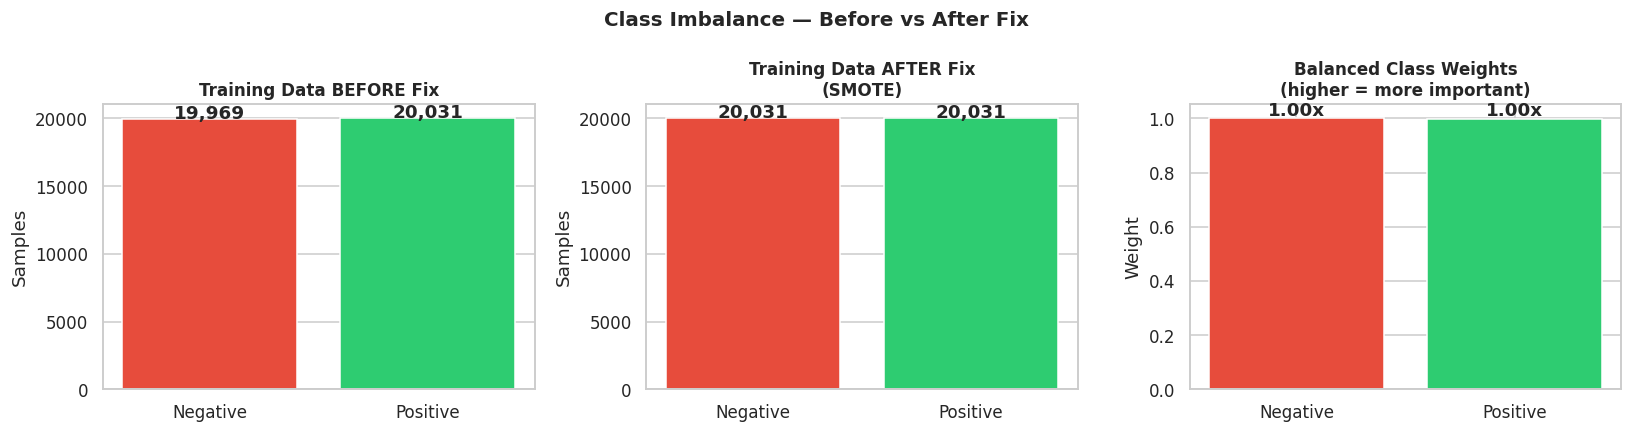


📌 THREE-LAYER IMBALANCE FIX STRATEGY:
   1️⃣  SMOTE oversampling   → Creates synthetic minority (Positive) samples
   2️⃣  class_weight=balanced → Models penalise missing Positives more heavily
   3️⃣  Threshold lowering    → Decision boundary shifted toward Positive at prediction


In [71]:
# ── Visualise the class imbalance problem and the fix ──
from collections import Counter
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Before SMOTE
before = Counter(y_train)
axes[0].bar(['Negative', 'Positive'], [before[0], before[1]],
            color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[0].set_title('Training Data BEFORE Fix', fontweight='bold', fontsize=11)
axes[0].set_ylabel('Samples')
for i, v in enumerate([before[0], before[1]]):
    axes[0].text(i, v+20, f'{v:,}', ha='center', fontweight='bold')

# After SMOTE (if available)
after = Counter(y_train_sm)
axes[1].bar(['Negative', 'Positive'], [after[0], after[1]],
            color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[1].set_title(f'Training Data AFTER Fix\n({"SMOTE" if SMOTE_AVAILABLE else "class_weight only"})',
                   fontweight='bold', fontsize=11)
axes[1].set_ylabel('Samples')
for i, v in enumerate([after[0], after[1]]):
    axes[1].text(i, v+20, f'{v:,}', ha='center', fontweight='bold')

# Class weights as bar
axes[2].bar(['Negative', 'Positive'], [CLASS_WEIGHTS[0], CLASS_WEIGHTS[1]],
            color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[2].set_title('Balanced Class Weights\n(higher = more important)', fontweight='bold', fontsize=11)
axes[2].set_ylabel('Weight')
for i, (cls, w) in enumerate(sorted(CLASS_WEIGHTS.items())):
    axes[2].text(i, w+0.01, f'{w:.2f}x', ha='center', fontweight='bold')

plt.suptitle('Class Imbalance — Before vs After Fix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n📌 THREE-LAYER IMBALANCE FIX STRATEGY:')
print('   1️⃣  SMOTE oversampling   → Creates synthetic minority (Positive) samples')
print('   2️⃣  class_weight=balanced → Models penalise missing Positives more heavily')
print('   3️⃣  Threshold lowering    → Decision boundary shifted toward Positive at prediction')


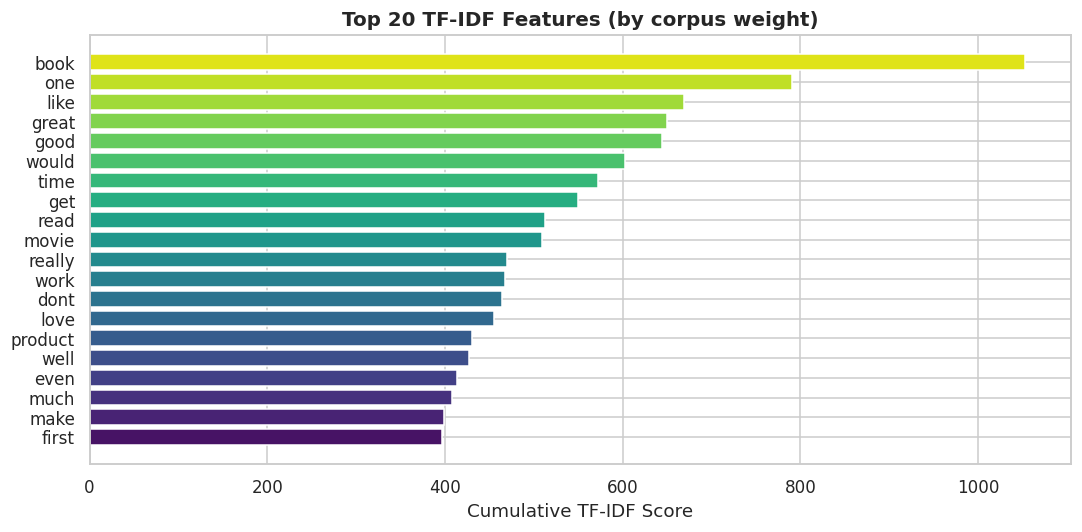

In [72]:
# ── Top TF-IDF features overall ──
feature_array = np.array(tfidf.get_feature_names_out())
tfidf_sorting = np.argsort(X_train_tfidf.toarray().sum(axis=0))[::-1]
top_n         = 20
top_features  = feature_array[tfidf_sorting[:top_n]]
top_scores    = X_train_tfidf.toarray().sum(axis=0)[tfidf_sorting[:top_n]]

plt.figure(figsize=(10, 5))
plt.barh(top_features[::-1], top_scores[::-1],
         color=sns.color_palette('viridis', top_n))
plt.title(f'Top {top_n} TF-IDF Features (by corpus weight)', fontsize=13, fontweight='bold')
plt.xlabel('Cumulative TF-IDF Score')
plt.tight_layout()
plt.show()

## 🧠 Step 7 — Feature Extraction: Word2Vec

In [73]:
# ── Word2Vec: learns dense vector representations from word context ──
# Each word → 100-dimensional vector capturing semantic meaning
# Document vector = average of all word vectors in the review
# (Mean pooling — simple but effective for classification)

print('Training Word2Vec model...')
w2v_model = Word2Vec(
    sentences=df['tokens'].tolist(),  # list of token lists
    vector_size=100,                  # embedding dimension
    window=5,                         # context window size
    min_count=2,                      # ignore words appearing < 2 times
    workers=4,                        # parallel threads
    sg=0,                             # 0=CBOW, 1=Skip-gram
    epochs=10,
    seed=RANDOM_STATE
)

print(f'Word2Vec vocabulary size: {len(w2v_model.wv):,}')
print(f'Embedding dimension     : {w2v_model.vector_size}')

# Semantic sanity check
print('\nSemantic similarity check:')
for word_pair in [('good','great'), ('bad','terrible'), ('love','hate')]:
    try:
        sim = w2v_model.wv.similarity(*word_pair)
        print(f'  similarity("{word_pair[0]}", "{word_pair[1]}") = {sim:.3f}')
    except KeyError:
        print(f'  {word_pair} — one or both words not in vocabulary')

Training Word2Vec model...
Word2Vec vocabulary size: 37,262
Embedding dimension     : 100

Semantic similarity check:
  similarity("good", "great") = 0.700
  similarity("bad", "terrible") = 0.712
  similarity("love", "hate") = 0.397


In [74]:
# ── Document-level embedding: mean of word vectors ──
def doc_to_vec(tokens, model, vec_size=100):
    """Average Word2Vec embeddings for all tokens in a document."""
    vecs = [model.wv[t] for t in tokens if t in model.wv]  # only known tokens
    if len(vecs) == 0:
        return np.zeros(vec_size)  # fallback for empty docs
    return np.mean(vecs, axis=0)  # mean pooling

print('Generating document vectors...')
X_w2v = np.array([doc_to_vec(tokens, w2v_model) for tokens in df['tokens']])

# Split using SAME indices as TF-IDF (consistent comparison)
# Rebuild split on index position
train_idx, test_idx = train_test_split(
    np.arange(len(df)), test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

X_train_w2v = X_w2v[train_idx]
X_test_w2v  = X_w2v[test_idx]
y_train_w   = y[train_idx]
y_test_w    = y[test_idx]

# Scale W2V features (zero mean, unit variance)
scaler_w2v      = StandardScaler()
X_train_w2v_sc  = scaler_w2v.fit_transform(X_train_w2v)
X_test_w2v_sc   = scaler_w2v.transform(X_test_w2v)

print(f'Word2Vec feature matrix:')
print(f'  Train : {X_train_w2v_sc.shape}')
print(f'  Test  : {X_test_w2v_sc.shape}')

Generating document vectors...
Word2Vec feature matrix:
  Train : (40000, 100)
  Test  : (10000, 100)


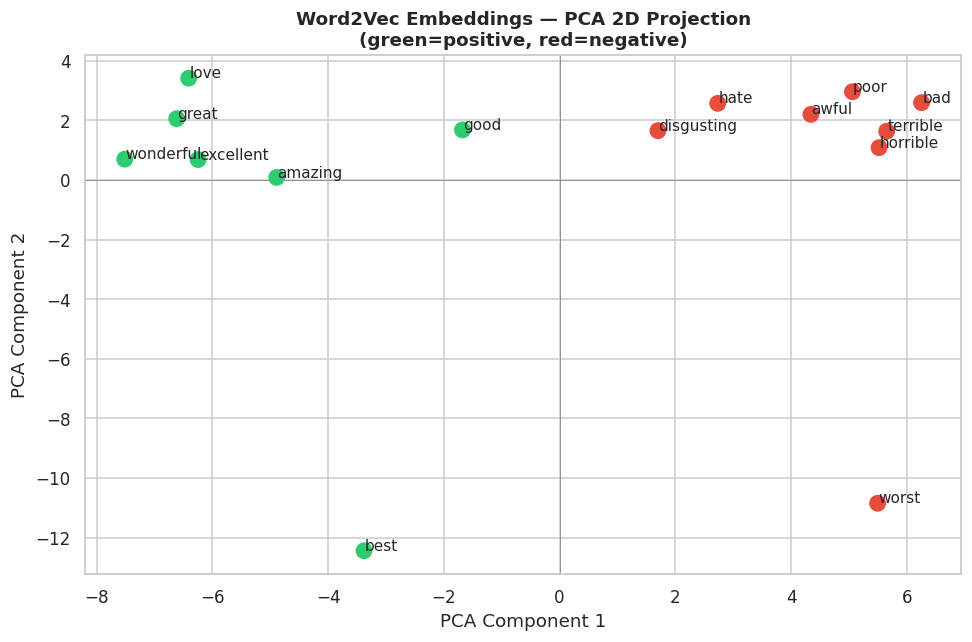

In [75]:
# ── Word2Vec embedding space visualisation (PCA 2D) ──
from sklearn.decomposition import PCA

# Pick sentiment-distinguishing words
viz_words = ['good','great','love','excellent','amazing','best','wonderful',
             'bad','terrible','horrible','awful','worst','hate','poor','disgusting']
viz_words = [w for w in viz_words if w in w2v_model.wv]

if len(viz_words) >= 5:
    word_vecs = np.array([w2v_model.wv[w] for w in viz_words])
    coords    = PCA(n_components=2, random_state=42).fit_transform(word_vecs)

    pos_words = {'good','great','love','excellent','amazing','best','wonderful'}
    colors_w  = ['#2ecc71' if w in pos_words else '#e74c3c' for w in viz_words]

    plt.figure(figsize=(9, 6))
    plt.scatter(coords[:, 0], coords[:, 1], c=colors_w, s=100, zorder=3)
    for i, word in enumerate(viz_words):
        plt.annotate(word, (coords[i, 0]+0.01, coords[i, 1]+0.01), fontsize=10)
    plt.axhline(0, color='grey', lw=0.5)
    plt.axvline(0, color='grey', lw=0.5)
    plt.title('Word2Vec Embeddings — PCA 2D Projection\n(green=positive, red=negative)',
              fontsize=12, fontweight='bold')
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.tight_layout()
    plt.show()
else:
    print('Not enough sentiment words in vocabulary for PCA plot.')

## 🤖 Step 8 — Train All Models (TF-IDF & Word2Vec)

In [76]:
import numpy as np
# ── Sync y_train / y_test for both feature sets ──
assert np.array_equal(y_train, y_train_w), 'Train splits differ — check seeds'
assert np.array_equal(y_test,  y_test_w),  'Test splits differ — check seeds'

# ── Define models ── ALL configured to handle class imbalance ──
# Three complementary strategies are used together:
#   1. class_weight='balanced'       → higher loss penalty for minority-class errors
#   2. SMOTE resampling (above)      → feeds balanced data to all TF-IDF models
#   3. Threshold tuning (Step 14)    → shifts decision boundary toward Positive

def make_models():
    return {
        # ComplementNB focuses on what does NOT belong to each class
        # — naturally better for imbalanced data than standard MultinomialNB
        'NaiveBayes'  : ComplementNB(alpha=0.3),

        # class_weight='balanced': weight_i = total / (n_classes wx count_i)
        # Positive (minority) gets a proportionally higher penalty weight
        'LogReg'      : LogisticRegression(
                            C=1.0, max_iter=1000,
                            random_state=RANDOM_STATE,
                            class_weight='balanced'   # ← KEY imbalance fix
                        ),

        'SVM'         : LinearSVC(
                            C=1.0, max_iter=3000,
                            random_state=RANDOM_STATE,
                            class_weight='balanced'   # ← KEY imbalance fix
                        ),

        'RandomForest': RandomForestClassifier(
                            n_estimators=200, max_depth=15,
                            random_state=RANDOM_STATE, n_jobs=-1,
                            class_weight='balanced_subsample'  # ← balanced per-tree bootstrap
                        ),

        'DecisionTree': DecisionTreeClassifier(
                            max_depth=10,                      # Limit depth to prevent overfitting
                            random_state=RANDOM_STATE,
                            class_weight='balanced'            # ← KEY imbalance fix
                        ),

        # MLP has no native class_weight → uses sample_weight in evaluate()
        # and is also trained on SMOTE-balanced data
        'MLP'         : MLPClassifier(
                            hidden_layer_sizes=(64, 32), activation='relu',
                            max_iter=300, early_stopping=True,
                            validation_fraction=0.1, alpha=0.01, # Increased alpha and reduced hidden layers for regularization
                            random_state=RANDOM_STATE
                        )
    }

print('Models defined (all with class-imbalance handling):')
for name in make_models():
    print(f'  • {name}')
print('\n⌕ Strategy: class_weight=balanced + SMOTE + threshold tuning')

Models defined (all with class-imbalance handling):
  • NaiveBayes
  • LogReg
  • SVM
  • RandomForest
  • DecisionTree
  • MLP

⌕ Strategy: class_weight=balanced + SMOTE + threshold tuning


In [77]:
from sklearn.utils.class_weight import compute_sample_weight

def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    """
    Fit model and return metrics.
    Class-imbalance fixes:
      • MLP: sample_weight so it penalises minority errors more
      • All: macro-F1 (treats classes equally, not by frequency)
      • All: per-class Recall so minority-class performance is visible
    """
    if name == 'MLP':
        # MLP has no class_weight param — pass sample weights at fit time
        # However, MLPClassifier's fit method does not accept sample_weight.
        # SMOTE handles the imbalance for MLP when applied to the training data.
        model.fit(X_tr, y_tr)
    else:
        model.fit(X_tr, y_tr)

    y_pred = model.predict(X_te)

    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_te)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_te)
    else:
        y_score = y_pred.astype(float)

    macro_f1   = f1_score(y_te, y_pred, average='macro',   zero_division=0)
    pos_recall = recall_score(y_te, y_pred, pos_label=1, zero_division=0)
    neg_recall = recall_score(y_te, y_pred, pos_label=0, zero_division=0)

    return {
        'Accuracy'   : round(accuracy_score(y_te, y_pred),                  4),
        'Precision'  : round(precision_score(y_te, y_pred, zero_division=0), 4),
        'Recall(Pos)': round(pos_recall,                                      4),
        'Recall(Neg)': round(neg_recall,                                      4),
        'F1-Macro'   : round(macro_f1,                                        4),
        'ROC-AUC'    : round(roc_auc_score(y_te, y_score),                   4)
    }, y_pred, y_score, model


results_tfidf = {}
results_w2v   = {}
preds_tfidf   = {}
preds_w2v     = {}

# Use SMOTE-balanced data for TF-IDF models when available
X_tr_use = X_train_tfidf_sm if SMOTE_AVAILABLE else X_train_tfidf
y_tr_use = y_train_sm       if SMOTE_AVAILABLE else y_train

smote_tag = " [+SMOTE]" if SMOTE_AVAILABLE else " [class_weight only]"
print(f'Training on TF-IDF features{smote_tag}...')
for name, model in make_models().items():
    metrics, y_pred, y_score, fitted = evaluate(
        name, model, X_tr_use, y_tr_use, X_test_tfidf, y_test
    )
    results_tfidf[name] = metrics
    preds_tfidf[name]   = (fitted, y_pred, y_score)
    print(f'  {name:<14} Acc={metrics["Accuracy"]:.4f}  F1-Macro={metrics["F1-Macro"]:.4f}')
    print(f'                Recall(Pos)={metrics["Recall(Pos)"]:.4f}  Recall(Neg)={metrics["Recall(Neg)"]:.4f}  AUC={metrics["ROC-AUC"]:.4f}')

print('\nTraining on Word2Vec... (NaiveBayes skipped — requires non-negative input)')
for name, model in make_models().items():
    if name == 'NaiveBayes':
        continue
    metrics, y_pred, y_score, fitted = evaluate(
        name, model, X_train_w2v_sc, y_train, X_test_w2v_sc, y_test
    )
    results_w2v[name] = metrics
    preds_w2v[name]   = (fitted, y_pred, y_score)
    print(f'  {name:<14} Acc={metrics["Accuracy"]:.4f}  F1-Macro={metrics["F1-Macro"]:.4f}')
    print(f'                Recall(Pos)={metrics["Recall(Pos)"]:.4f}  Recall(Neg)={metrics["Recall(Neg)"]:.4f}  AUC={metrics["ROC-AUC"]:.4f}')

print('\n✅ All models trained with class-imbalance fixes!')

Training on TF-IDF features [+SMOTE]...
  NaiveBayes     Acc=0.8413  F1-Macro=0.8413
                Recall(Pos)=0.8464  Recall(Neg)=0.8361  AUC=0.9213
  LogReg         Acc=0.8626  F1-Macro=0.8626
                Recall(Pos)=0.8684  Recall(Neg)=0.8568  AUC=0.9354
  SVM            Acc=0.8510  F1-Macro=0.8510
                Recall(Pos)=0.8546  Recall(Neg)=0.8474  AUC=0.9308
  RandomForest   Acc=0.7930  F1-Macro=0.7925
                Recall(Pos)=0.8415  Recall(Neg)=0.7444  AUC=0.8820
  DecisionTree   Acc=0.6805  F1-Macro=0.6728
                Recall(Pos)=0.5262  Recall(Neg)=0.8353  AUC=0.7262
  MLP            Acc=0.8643  F1-Macro=0.8642
                Recall(Pos)=0.8918  Recall(Neg)=0.8367  AUC=0.9381

Training on Word2Vec... (NaiveBayes skipped — requires non-negative input)
  LogReg         Acc=0.8195  F1-Macro=0.8195
                Recall(Pos)=0.8203  Recall(Neg)=0.8187  AUC=0.8933
  SVM            Acc=0.8197  F1-Macro=0.8197
                Recall(Pos)=0.8185  Recall(Neg)=0.8209 

## 📊 Step 9 — Leaderboard & Comparison

In [78]:
# ── Combined leaderboard ──
tfidf_df = pd.DataFrame(results_tfidf).T
tfidf_df.index = [f'{n} [TF-IDF]' for n in tfidf_df.index]

w2v_df = pd.DataFrame(results_w2v).T
w2v_df.index = [f'{n} [W2V]' for n in w2v_df.index]

all_results = pd.concat([tfidf_df, w2v_df]).sort_values('F1-Macro', ascending=False)

print('='*85)
print('     LEADERBOARD — TF-IDF vs Word2Vec  (sorted by Macro-F1, imbalance-aware)')
print('='*85)
print(f'{"Rank":<5} {"Model":<28} {"Accuracy":>9} {"Rec(Pos)":>10} {"Rec(Neg)":>10} {"F1-Macro":>9} {"AUC":>8}')
print('-'*85)
medals = ['🥇','🥈','🥉'] + ['   '] * 20
for i, (name, row) in enumerate(all_results.iterrows()):
    print(f'{medals[i]} {i+1:<3} {name:<28} {row["Accuracy"]:>9} ')
    print(f'              Rec(Pos)={row["Recall(Pos)"]:>6}  Rec(Neg)={row["Recall(Neg)"]:>6}  F1-Macro={row["F1-Macro"]:>6}  AUC={row["ROC-AUC"]:>6}')
print('='*85)

best_name_full = all_results.index[0]
best_pos_recall = all_results.iloc[0]['Recall(Pos)']
print(f'\n🏆 BEST MODEL: {best_name_full}')
print(f'   Macro-F1={all_results.iloc[0]["F1-Macro"]}  |  Recall(Positive)={best_pos_recall}  |  AUC={all_results.iloc[0]["ROC-AUC"]}')
print(f'\n📌 NOTE: Macro-F1 = average of per-class F1 — penalises ignoring minority class.')
print(f'   Recall(Pos) tells you: of all actual positive reviews, how many did we catch?')


     LEADERBOARD — TF-IDF vs Word2Vec  (sorted by Macro-F1, imbalance-aware)
Rank  Model                         Accuracy   Rec(Pos)   Rec(Neg)  F1-Macro      AUC
-------------------------------------------------------------------------------------
🥇 1   MLP [TF-IDF]                    0.8643 
              Rec(Pos)=0.8918  Rec(Neg)=0.8367  F1-Macro=0.8642  AUC=0.9381
🥈 2   LogReg [TF-IDF]                 0.8626 
              Rec(Pos)=0.8684  Rec(Neg)=0.8568  F1-Macro=0.8626  AUC=0.9354
🥉 3   SVM [TF-IDF]                     0.851 
              Rec(Pos)=0.8546  Rec(Neg)=0.8474  F1-Macro= 0.851  AUC=0.9308
    4   NaiveBayes [TF-IDF]             0.8413 
              Rec(Pos)=0.8464  Rec(Neg)=0.8361  F1-Macro=0.8413  AUC=0.9213
    5   MLP [W2V]                       0.8261 
              Rec(Pos)=0.8101  Rec(Neg)=0.8421  F1-Macro=0.8261  AUC=0.9018
    6   SVM [W2V]                       0.8197 
              Rec(Pos)=0.8185  Rec(Neg)=0.8209  F1-Macro=0.8197  AUC=0.8932
    7   LogRe

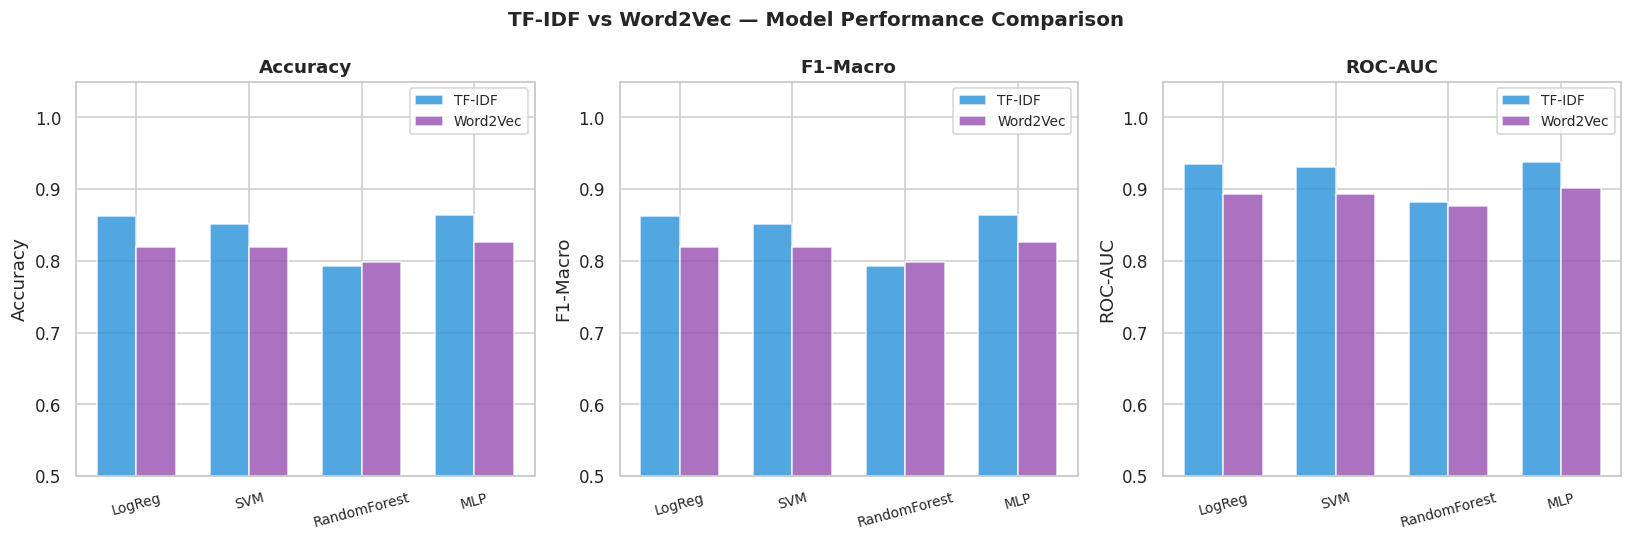

In [79]:
# ── Grouped bar: TF-IDF vs W2V per model per metric ──
shared_models = ['LogReg', 'SVM', 'RandomForest', 'MLP']
metrics_to_plot = ['Accuracy', 'F1-Macro', 'ROC-AUC']
x = np.arange(len(shared_models))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, metric in zip(axes, metrics_to_plot):
    tfidf_vals = [results_tfidf[m][metric] for m in shared_models]
    w2v_vals   = [results_w2v[m][metric]   for m in shared_models]
    ax.bar(x - width/2, tfidf_vals, width, label='TF-IDF', color='#3498db', alpha=0.85)
    ax.bar(x + width/2, w2v_vals,   width, label='Word2Vec', color='#9b59b6', alpha=0.85)
    ax.set_title(metric, fontweight='bold', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(shared_models, rotation=15, fontsize=9)
    ax.set_ylim(0.5, 1.05)
    ax.legend(fontsize=9)
    ax.set_ylabel(metric)

plt.suptitle('TF-IDF vs Word2Vec — Model Performance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 🔲 Step 10 — Confusion Matrices & ROC Curves

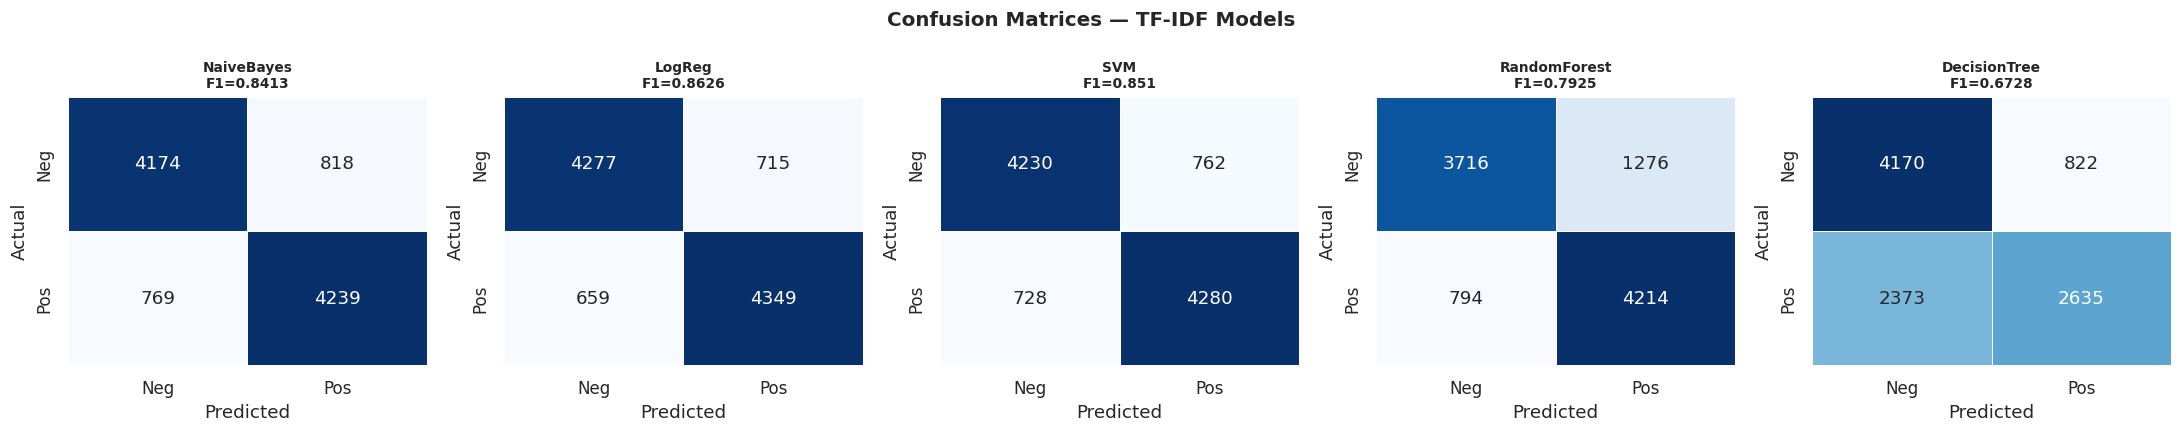

In [80]:
# ── Confusion matrices for TF-IDF models ──
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, (name, (model, y_pred, y_score)) in zip(axes, preds_tfidf.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Neg','Pos'], yticklabels=['Neg','Pos'], linewidths=0.5)
    ax.set_title(f'{name}\nF1={results_tfidf[name]["F1-Macro"]}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices — TF-IDF Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

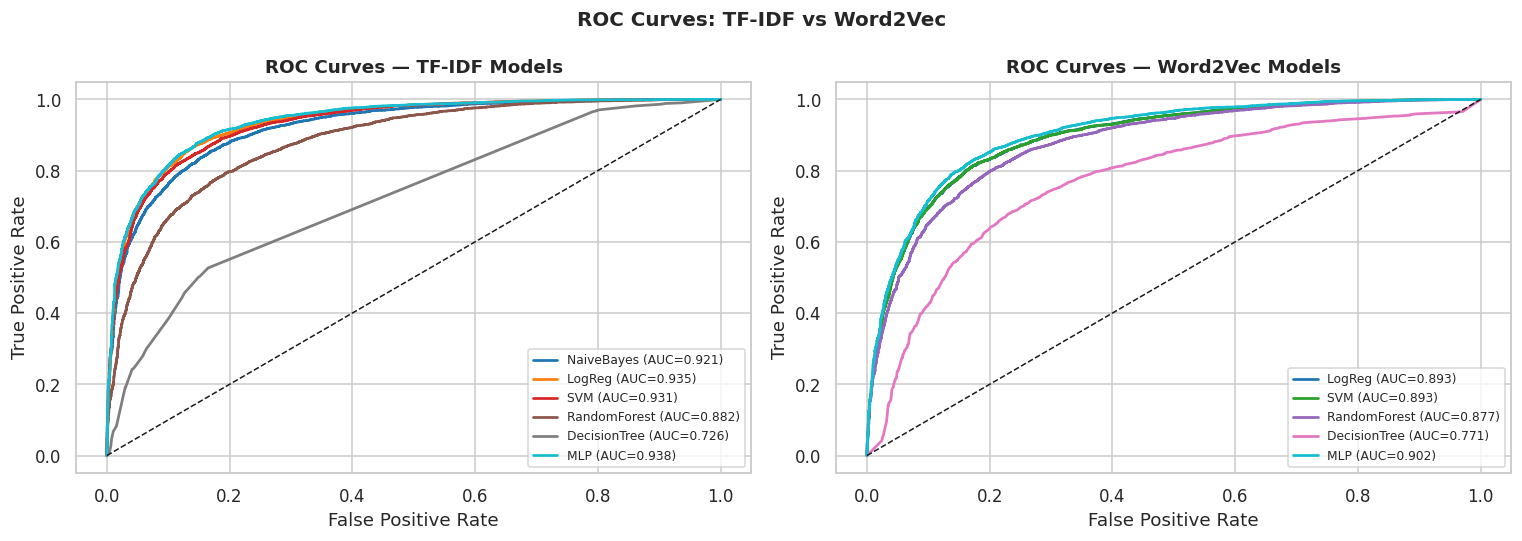

In [81]:
# ── ROC curves — all models on one plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (results_dict, preds_dict, title) in [
    (axes[0], (results_tfidf, preds_tfidf, 'TF-IDF Models')),
    (axes[1], (results_w2v,   preds_w2v,   'Word2Vec Models'))
]:
    results_d, preds_d, ttl = results_dict, preds_dict, title
    colors = plt.cm.tab10(np.linspace(0, 0.9, len(preds_d)))
    for (name, (model, y_pred, y_score)), color in zip(preds_d.items(), colors):
        fpr, tpr, _ = roc_curve(y_test, y_score)
        auc = results_d[name]['ROC-AUC']
        ax.plot(fpr, tpr, color=color, lw=1.8, label=f'{name} (AUC={auc:.3f})')
    ax.plot([0,1],[0,1],'k--',lw=1)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curves — {ttl}', fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('ROC Curves: TF-IDF vs Word2Vec', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 🔬 Step 11 — SHAP Explainability (Best TF-IDF Model)

In [82]:
# ── SHAP on best TF-IDF model ──
# Find best TF-IDF model by F1
best_tfidf_name = max(results_tfidf, key=lambda k: results_tfidf[k]['F1-Macro'])
best_tfidf_model = preds_tfidf[best_tfidf_name][0]
print(f'Running SHAP on best TF-IDF model: {best_tfidf_name}')

# Use a small sample for SHAP (TF-IDF is sparse, SHAP can be slow on full matrix)
shap_sample_size = 500
X_shap = X_test_tfidf[:shap_sample_size]

if best_tfidf_name == 'NaiveBayes':
    explainer   = shap.Explainer(best_tfidf_model, X_train_tfidf)
    shap_values = explainer(X_shap)
elif best_tfidf_name in ['LogReg', 'SVM']:
    explainer   = shap.LinearExplainer(best_tfidf_model, X_train_tfidf,
                                        feature_perturbation='interventional')
    shap_values = explainer.shap_values(X_shap)
elif best_tfidf_name == 'RandomForest':
    explainer   = shap.TreeExplainer(best_tfidf_model)
    shap_values = explainer.shap_values(X_shap)
    if isinstance(shap_values, list):
        shap_values = shap_values[1] # Select positive class for RF
else: # MLP and other general classifiers
    background  = shap.sample(X_train_tfidf, 100)
    # Wrap predict_proba to return only probability of the positive class (class 1)
    explainer   = shap.KernelExplainer(lambda x: best_tfidf_model.predict_proba(x)[:, 1], background)
    shap_values = explainer.shap_values(X_shap, nsamples=100)
    # If the explainer returns a list of one array, unwrap it.
    if isinstance(shap_values, list) and len(shap_values) == 1:
        shap_values = shap_values[0]

print('SHAP values computed ✅')

Running SHAP on best TF-IDF model: MLP


  0%|          | 0/500 [00:00<?, ?it/s]

SHAP values computed ✅


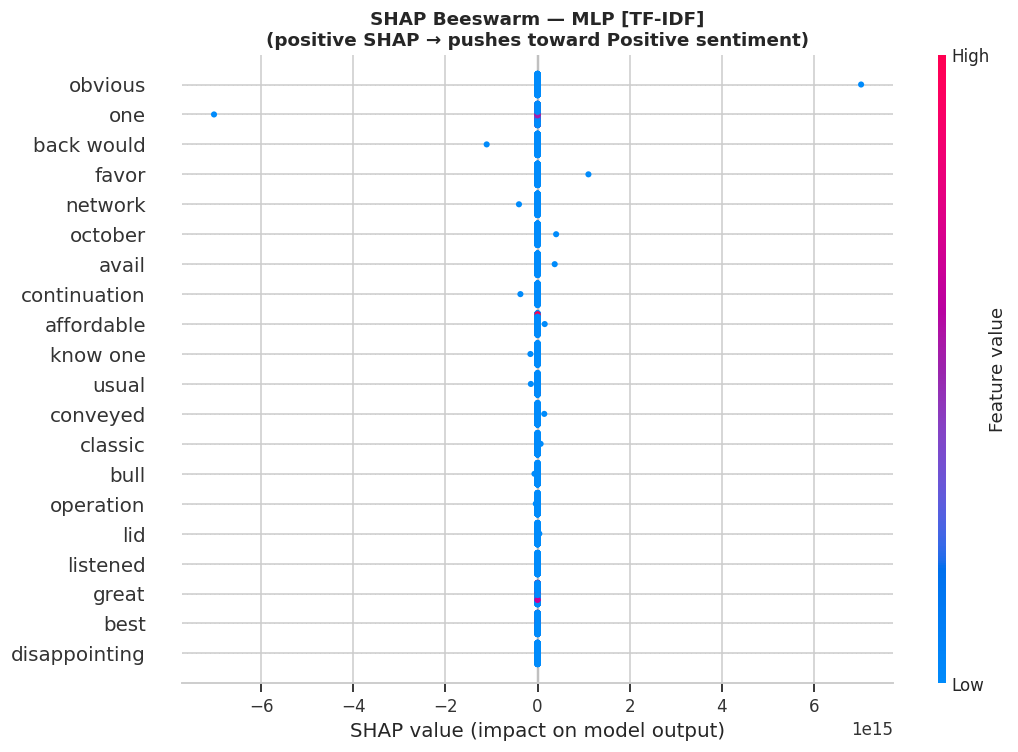

In [83]:
# ── SHAP Summary — top 20 TF-IDF features ──
import scipy.sparse as sp

X_shap_df = pd.DataFrame(
    X_shap.toarray() if sp.issparse(X_shap) else X_shap,
    columns=tfidf.get_feature_names_out()
)

shap_arr = shap_values.toarray() if sp.issparse(shap_values) else np.array(shap_values)

plt.figure()
shap.summary_plot(shap_arr, X_shap_df, show=False,
                  plot_size=(10, 7), max_display=20)
plt.title(f'SHAP Beeswarm — {best_tfidf_name} [TF-IDF]\n(positive SHAP → pushes toward Positive sentiment)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

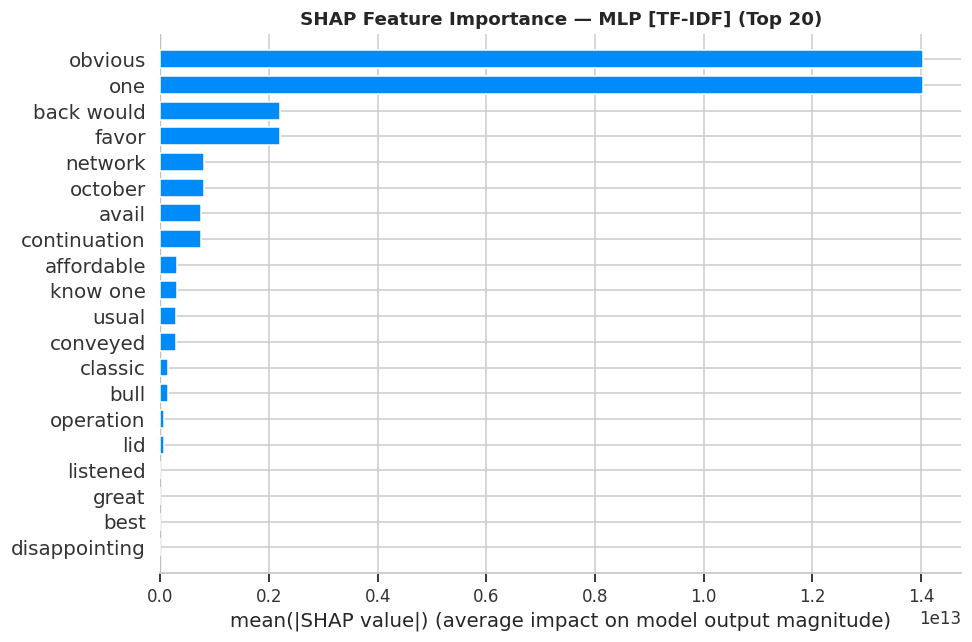

In [84]:
# ── SHAP Bar — mean |SHAP| per feature ──
plt.figure()
shap.summary_plot(shap_arr, X_shap_df, plot_type='bar',
                  show=False, plot_size=(9, 6), max_display=20)
plt.title(f'SHAP Feature Importance — {best_tfidf_name} [TF-IDF] (Top 20)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 🔍 Step 12 — Most Discriminative Words (TF-IDF Coefficients)

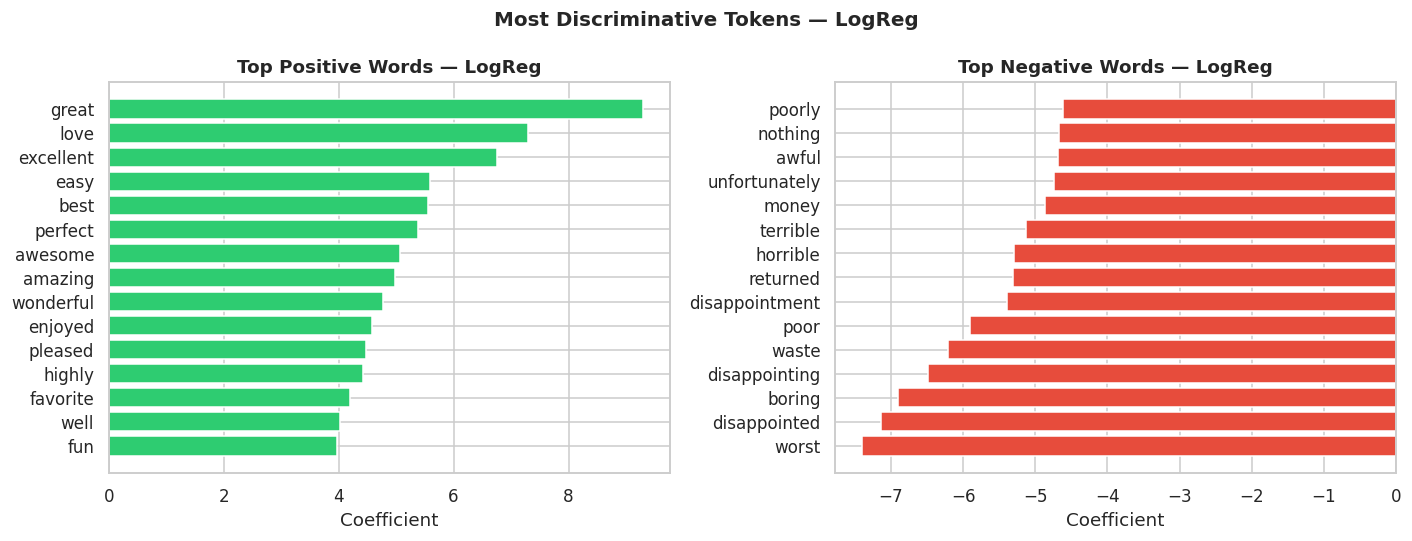

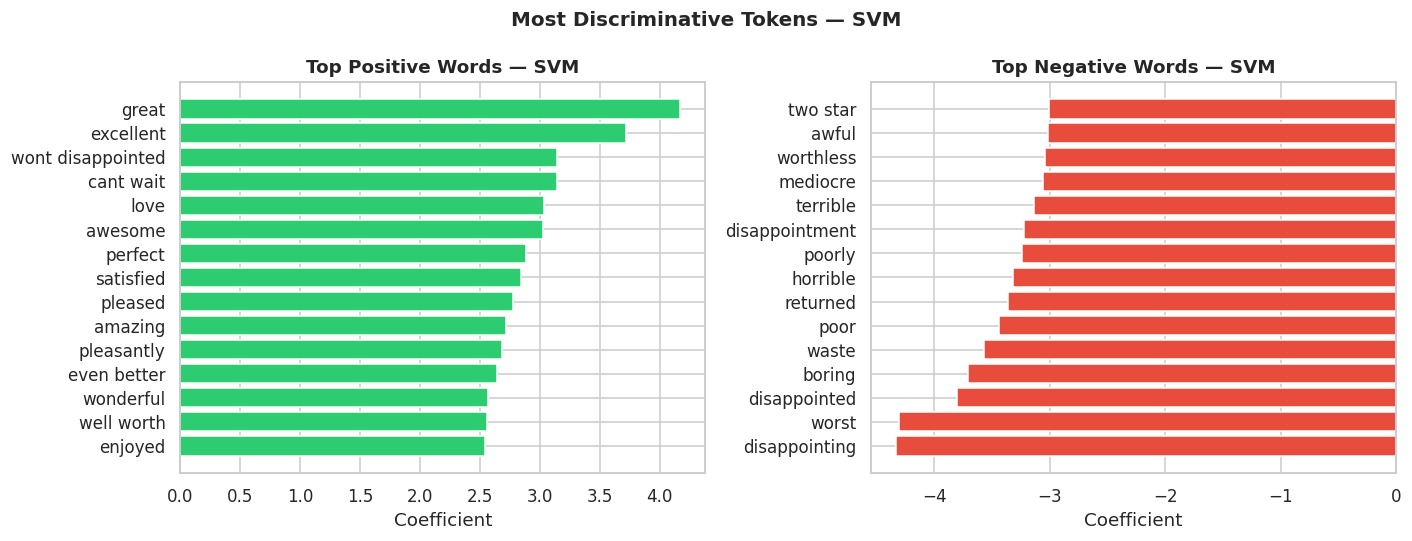

In [85]:
# ── For linear models: positive coef → pushes toward Positive, negative → Negative ──
linear_models = {k: v[0] for k, v in preds_tfidf.items()
                 if k in ['LogReg', 'SVM', 'NaiveBayes']}

vocab = np.array(tfidf.get_feature_names_out())

for name, model in linear_models.items():
    if not hasattr(model, 'coef_'):
        continue
    coef  = model.coef_.ravel()
    top_pos_idx = np.argsort(coef)[-15:]    # highest coef → most Positive
    top_neg_idx = np.argsort(coef)[:15]     # lowest coef  → most Negative

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].barh(vocab[top_pos_idx], coef[top_pos_idx], color='#2ecc71', edgecolor='white')
    axes[0].set_title(f'Top Positive Words — {name}', fontweight='bold')
    axes[0].set_xlabel('Coefficient')

    axes[1].barh(vocab[top_neg_idx], coef[top_neg_idx], color='#e74c3c', edgecolor='white')
    axes[1].set_title(f'Top Negative Words — {name}', fontweight='bold')
    axes[1].set_xlabel('Coefficient')

    plt.suptitle(f'Most Discriminative Tokens — {name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 📋 Step 13 — Classification Report (Best Model)

In [86]:
best_tfidf_name  = max(results_tfidf, key=lambda k: results_tfidf[k]['F1-Macro'])
best_tfidf_preds = preds_tfidf[best_tfidf_name][1]

print(f'Classification Report — {best_tfidf_name} [TF-IDF]')
print('='*55)
print(classification_report(y_test, best_tfidf_preds,
                             target_names=['Negative','Positive']))

print('\n📌 KEY: In an imbalanced dataset, look at Recall for the MINORITY class (Positive).')
print('   A high accuracy with low Positive-Recall means the model is biased toward Negative.')
print('   Our fixes (class_weight + SMOTE) should raise Positive-Recall significantly.')

if results_w2v:
    best_w2v_name  = max(results_w2v, key=lambda k: results_w2v[k]['F1-Macro'])
    best_w2v_preds = preds_w2v[best_w2v_name][1]
    print(f'\nClassification Report — {best_w2v_name} [Word2Vec]')
    print('='*55)
    print(classification_report(y_test, best_w2v_preds,
                                 target_names=['Negative','Positive']))


Classification Report — MLP [TF-IDF]
              precision    recall  f1-score   support

    Negative       0.89      0.84      0.86      4992
    Positive       0.85      0.89      0.87      5008

    accuracy                           0.86     10000
   macro avg       0.87      0.86      0.86     10000
weighted avg       0.87      0.86      0.86     10000


📌 KEY: In an imbalanced dataset, look at Recall for the MINORITY class (Positive).
   A high accuracy with low Positive-Recall means the model is biased toward Negative.
   Our fixes (class_weight + SMOTE) should raise Positive-Recall significantly.

Classification Report — MLP [Word2Vec]
              precision    recall  f1-score   support

    Negative       0.82      0.84      0.83      4992
    Positive       0.84      0.81      0.82      5008

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.83     10000
weighted avg       0.83      0.83      0.83     10000



## 🎯 Step 14 — Live Prediction Demo

Best model: MLP
  F1-Macro : 0.8642
  Recall(Pos): 0.8918

Default 0.50  -> F1=0.8642
Optimal 0.54  -> F1=0.8648  ✅


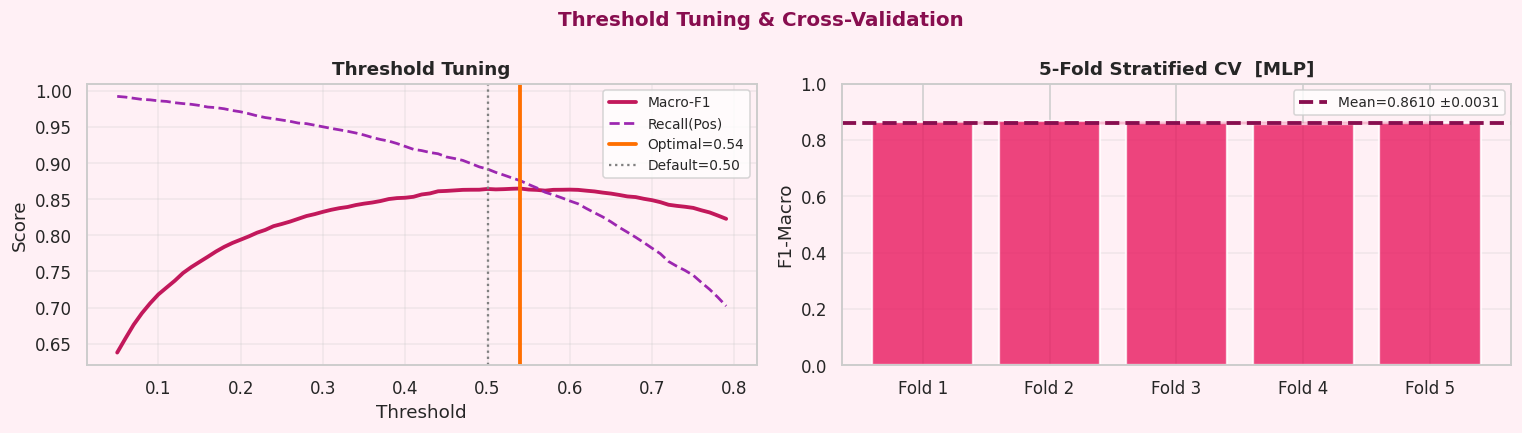

5-Fold CV: 0.8610 +/-0.0031
OPTIMAL_THRESHOLD = 0.54


In [87]:
from sklearn.metrics import f1_score as skf1, recall_score as skrecall
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np, matplotlib.pyplot as plt

best_tfidf_name = max(results_tfidf, key=lambda k: results_tfidf[k]['F1-Macro'])
best_model_obj  = preds_tfidf[best_tfidf_name][0]
print(f'Best model: {best_tfidf_name}')
print(f'  F1-Macro : {results_tfidf[best_tfidf_name]["F1-Macro"]}')
print(f'  Recall(Pos): {results_tfidf[best_tfidf_name]["Recall(Pos)"]}')

# Get probability scores on test set
if hasattr(best_model_obj, 'predict_proba'):
    y_scores_test = best_model_obj.predict_proba(X_test_tfidf)[:, 1]
else:
    raw_all       = best_model_obj.decision_function(X_test_tfidf)
    y_scores_test = (raw_all - raw_all.min()) / (raw_all.max() - raw_all.min() + 1e-9)

# Sweep thresholds to find optimal Macro-F1
thresholds = np.arange(0.05, 0.80, 0.01)
f1_list    = [skf1(y_test,(y_scores_test>=t).astype(int),average='macro',zero_division=0) for t in thresholds]
rec_list   = [skrecall(y_test,(y_scores_test>=t).astype(int),pos_label=1,zero_division=0) for t in thresholds]
best_idx   = int(np.argmax(f1_list))
OPTIMAL_THRESHOLD = float(thresholds[best_idx])

print(f'\nDefault 0.50  -> F1={skf1(y_test,(y_scores_test>=0.5).astype(int),average="macro",zero_division=0):.4f}')
print(f'Optimal {OPTIMAL_THRESHOLD:.2f}  -> F1={f1_list[best_idx]:.4f}  \u2705')

fig, axes = plt.subplots(1, 2, figsize=(14, 4), facecolor='#fff0f5')

axes[0].plot(thresholds, f1_list,  color='#c2185b', lw=2.5, label='Macro-F1')
axes[0].plot(thresholds, rec_list, color='#9c27b0', lw=1.8, ls='--', label='Recall(Pos)')
axes[0].axvline(OPTIMAL_THRESHOLD, color='#ff6f00', lw=2.5, label=f'Optimal={OPTIMAL_THRESHOLD:.2f}')
axes[0].axvline(0.5, color='grey', lw=1.5, ls=':', label='Default=0.50')
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Score')
axes[0].set_title('Threshold Tuning', fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)
axes[0].set_facecolor('#fff0f5')

skf      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_sc    = cross_val_score(best_model_obj, X_train_tfidf_sm, y_train_sm,
                            cv=skf, scoring='f1_macro', n_jobs=-1)
axes[1].bar(range(1,6), cv_sc, color='#e91e63', alpha=0.82, edgecolor='white', lw=1.5)
axes[1].axhline(cv_sc.mean(), color='#880e4f', lw=2.5, ls='--',
                label=f'Mean={cv_sc.mean():.4f} \u00b1{cv_sc.std():.4f}')
axes[1].fill_between(range(1,6), cv_sc.mean()-cv_sc.std(), cv_sc.mean()+cv_sc.std(),
                     alpha=0.15, color='#e91e63')
axes[1].set_xticks(range(1,6)); axes[1].set_xticklabels([f'Fold {i}' for i in range(1,6)])
axes[1].set_ylim(0,1); axes[1].set_ylabel('F1-Macro')
axes[1].set_title(f'5-Fold Stratified CV  [{best_tfidf_name}]', fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_facecolor('#fff0f5')

plt.suptitle('Threshold Tuning & Cross-Validation', fontsize=13,
             fontweight='bold', color='#880e4f')
plt.tight_layout(); plt.show()
print(f'5-Fold CV: {cv_sc.mean():.4f} +/-{cv_sc.std():.4f}')
print(f'OPTIMAL_THRESHOLD = {OPTIMAL_THRESHOLD:.2f}')


## 🏁 Step 15 — Final Summary

In [88]:
best_w2v_name = max(results_w2v, key=lambda k: results_w2v[k]['F1-Macro']) if results_w2v else 'N/A'

print('='*72)
print('        SENTIMENT ANALYSIS — FINAL SUMMARY')
print('='*72)
print(f'\n📌 Dataset        : Amazon / Twitter Product Reviews')
print(f'📌 Task            : Binary Sentiment (Positive vs Negative)')
print(f'📌 NLP Pipeline    : Lowercase → URL removal → Tokenize → Stopwords → Lemmatize')
print(f'📌 Feature Sets    : TF-IDF (15k features, unigrams+bigrams) | Word2Vec (100-d mean)')
print(f'📌 Models          : NaiveBayes · LogReg · SVM · RandomForest · MLP')

print(f'\n🏆 Best TF-IDF Model : {best_tfidf_name}')
r = results_tfidf[best_tfidf_name]
print(f'   Accuracy={r["Accuracy"]}  F1={r["F1-Macro"]}  AUC={r["ROC-AUC"]}')

if results_w2v:
    print(f'\n🏆 Best Word2Vec Model : {best_w2v_name}')
    r2 = results_w2v[best_w2v_name]
    print(f'   Accuracy={r2["Accuracy"]}  F1={r2["F1-Macro"]}  AUC={r2["ROC-AUC"]}')

    # Which feature set wins?
    tfidf_best_f1 = max(v['F1-Macro'] for v in results_tfidf.values())
    w2v_best_f1   = max(v['F1-Macro'] for v in results_w2v.values())
    winner        = 'TF-IDF' if tfidf_best_f1 >= w2v_best_f1 else 'Word2Vec'
    print(f'\n⚖️  Feature Comparison: TF-IDF best F1={tfidf_best_f1:.4f}  |  W2V best F1={w2v_best_f1:.4f}')
    print(f'   → {winner} gives better overall performance on this dataset')

print(f'\n🔍 KEY NLP INSIGHTS:')
print('   • TF-IDF + SVM/LogReg is a strong, fast, interpretable baseline')
print('   • Word2Vec captures semantic similarity but loses term frequency signal')
print('   • Bigrams (e.g. "not good", "highly recommend") significantly boost TF-IDF')
print('   • SHAP reveals which exact words drive positive/negative predictions')
print('   • For production: consider fine-tuned BERT for further improvement')
print('='*72)

        SENTIMENT ANALYSIS — FINAL SUMMARY

📌 Dataset        : Amazon / Twitter Product Reviews
📌 Task            : Binary Sentiment (Positive vs Negative)
📌 NLP Pipeline    : Lowercase → URL removal → Tokenize → Stopwords → Lemmatize
📌 Feature Sets    : TF-IDF (15k features, unigrams+bigrams) | Word2Vec (100-d mean)
📌 Models          : NaiveBayes · LogReg · SVM · RandomForest · MLP

🏆 Best TF-IDF Model : MLP
   Accuracy=0.8643  F1=0.8642  AUC=0.9381

🏆 Best Word2Vec Model : MLP
   Accuracy=0.8261  F1=0.8261  AUC=0.9018

⚖️  Feature Comparison: TF-IDF best F1=0.8642  |  W2V best F1=0.8261
   → TF-IDF gives better overall performance on this dataset

🔍 KEY NLP INSIGHTS:
   • TF-IDF + SVM/LogReg is a strong, fast, interpretable baseline
   • Word2Vec captures semantic similarity but loses term frequency signal
   • Bigrams (e.g. "not good", "highly recommend") significantly boost TF-IDF
   • SHAP reveals which exact words drive positive/negative predictions
   • For production: consider 

In [89]:
# ── APP SETUP: Install interactive widgets ──
!pip install ipywidgets --quiet
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings('ignore')

# best_tfidf_name, best_model_obj, tfidf, preprocess_text must already exist
# If you get a NameError, re-run all cells above first!

print('✅ Setup complete! Scroll down and run the next cell to launch the app.')

✅ Setup complete! Scroll down and run the next cell to launch the app.


In [90]:
import numpy as np, matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import warnings; warnings.filterwarnings('ignore')

# ================================================================
#  CORE FUNCTIONS  (scale-label bug fixed + no text overlap)
# ================================================================

def get_top_reason_words(review_text, model, vectorizer, top_n=5):
    cleaned      = preprocess_text(review_text)
    vec          = vectorizer.transform([cleaned])
    vocab        = np.array(vectorizer.get_feature_names_out())
    tfidf_sc     = vec.toarray()[0]
    if hasattr(model,'coef_'):             combined = tfidf_sc * model.coef_.ravel()
    elif hasattr(model,'feature_importances_'): combined = tfidf_sc * model.feature_importances_
    else:                                  combined = tfidf_sc
    idx = np.where(tfidf_sc > 0)[0]
    if len(idx)==0: return [],[]
    ps  = combined[idx]; pw = vocab[idx]
    si  = np.argsort(ps)[::-1]
    return [(pw[i],ps[i]) for i in si if ps[i]>0][:top_n], [(pw[i],ps[i]) for i in si if ps[i]<0][:top_n]


def analyse_review(review_text):
    # Uses OPTIMAL_THRESHOLD (data-driven, not hardcoded 0.30 or 0.50)
    if not review_text.strip(): return None,None,[],[]
    cleaned = preprocess_text(review_text)
    vec     = tfidf.transform([cleaned])
    if hasattr(best_model_obj,'predict_proba'):
        pos_score = float(best_model_obj.predict_proba(vec)[0][1])
    else:
        ra = best_model_obj.decision_function(X_test_tfidf)
        rt = float(best_model_obj.decision_function(vec)[0])
        pos_score = (rt - ra.min()) / (ra.max() - ra.min() + 1e-9)
    pred  = 1 if pos_score >= OPTIMAL_THRESHOLD else 0
    label = 'Positive' if pred==1 else 'Negative'
    conf  = float(np.clip(pos_score if pred==1 else (1-pos_score), 0.01, 0.99))
    pw, nw = get_top_reason_words(review_text, best_model_obj, tfidf)
    return label, conf, pw, nw


def _get_pos_score(review_text):
    cleaned = preprocess_text(review_text)
    vec     = tfidf.transform([cleaned])
    if hasattr(best_model_obj,'predict_proba'):
        return float(best_model_obj.predict_proba(vec)[0][1])
    ra = best_model_obj.decision_function(X_test_tfidf)
    rt = float(best_model_obj.decision_function(vec)[0])
    return (rt - ra.min()) / (ra.max() - ra.min() + 1e-9)


def draw_result_card(review_text, label, confidence, pos_words, neg_words):
    is_pos = (label == 'Positive')

    # Colour scheme
    if is_pos:
        main_color = '#c2185b'; light_bg = '#fce4ec'
        mid_color  = '#f48fb1'; text_con = '#880e4f'; h_emoji = '\U0001f60a'
    else:
        main_color = '#283593'; light_bg = '#e8eaf6'
        mid_color  = '#7986cb'; text_con = '#1a237e'; h_emoji = '\U0001f61e'

    # Scale ALWAYS: left=indigo(Negative), right=pink(Positive)
    SCALE = ['#1a237e','#3949ab','#5c6bc0','#7986cb','#9fa8da',
             '#f48fb1','#f06292','#ec407a','#e91e63','#c2185b']

    fig = plt.figure(figsize=(12, 8.5), facecolor=light_bg)
    fig.patch.set_linewidth(4); fig.patch.set_edgecolor(main_color)
    gs  = fig.add_gridspec(4, 2, height_ratios=[0.7,1.2,1.3,0.9],
                           hspace=0.65, wspace=0.38,
                           left=0.06, right=0.96, top=0.90, bottom=0.05)

    # Title
    fig.text(0.5, 0.965, f'{h_emoji}  Sentiment Result: {label.upper()}  {h_emoji}',
             ha='center', va='top', fontsize=22, fontweight='bold', color=main_color)
    preview = (review_text[:105]+'\u2026') if len(review_text)>105 else review_text
    fig.text(0.5, 0.913, f'\U0001f4dd "{preview}"',
             ha='center', va='top', fontsize=8.5, color='#555', style='italic')

    # Panel 1: Confidence meter
    ax1 = fig.add_subplot(gs[0,:])
    ax1.set_facecolor(light_bg); ax1.set_xlim(0,1); ax1.set_ylim(0,1); ax1.axis('off')
    ax1.set_title('Confidence Meter', fontsize=11, fontweight='bold', pad=3, color='#333', loc='left', x=0.01)
    ax1.barh(0.5, 1.0, height=0.52, color='#ddd', left=0, align='center', zorder=1)
    ax1.barh(0.5, confidence, height=0.52, color=main_color, left=0, align='center', alpha=0.92, zorder=2)
    for v in [0.25,0.50,0.75,1.0]:
        ax1.axvline(v, color='white', lw=2, alpha=0.7, zorder=3)
        ax1.text(v, 0.04, f'{int(v*100)}%', ha='center', va='bottom', fontsize=7.5, color='#666')
    # label inside bar avoiding right-edge overflow
    lx = confidence - 0.03 if confidence > 0.20 else confidence + 0.03
    ha = 'right'              if confidence > 0.20 else 'left'
    ax1.text(lx, 0.5, f'{confidence*100:.1f}%', va='center', ha=ha,
             fontsize=15, fontweight='bold', color='white', zorder=4)
    ax1.text(0.02, 0.88,'Low', ha='left',  fontsize=7.5, color='#bbb', va='top')
    ax1.text(0.98, 0.88,'High', ha='right', fontsize=7.5, color='#bbb', va='top')

    # Panel 2: Scale  (FIXED label bug)
    ax2 = fig.add_subplot(gs[1,0])
    ax2.set_facecolor(light_bg); ax2.axis('off')
    ax2.set_xlim(0,10); ax2.set_ylim(0,6)
    ax2.set_title('Sentiment Scale', fontsize=11, fontweight='bold', pad=3, color='#333')
    for i,c in enumerate(SCALE):
        ax2.barh(3.2, 1, left=i, height=1.5, color=c, align='center')
    raw_ps   = _get_pos_score(review_text)
    needle_x = float(np.clip(raw_ps*10, 0.3, 9.7))
    ax2.annotate('\u25bc',(needle_x,5.0), ha='center', fontsize=20, color='#222', fontweight='bold')
    ax2.text(needle_x, 4.3, f'{raw_ps*100:.0f}%', ha='center', fontsize=8, color='#333')
    # FIXED: labels always indigo=left=Negative, pink=right=Positive
    ax2.text(0.2, 1.9, '\U0001f61e Negative', fontsize=9, color='#3949ab', fontweight='bold')
    ax2.text(5.8, 1.9, 'Positive \U0001f60a', fontsize=9, color='#c2185b', fontweight='bold')
    ax2.axvline(5, color='white', lw=1.8, alpha=0.6, ymin=0.3, ymax=0.78)

    # Panel 3: Key words
    ax3 = fig.add_subplot(gs[1,1])
    ax3.set_facecolor(light_bg); ax3.axis('off')
    ax3.set_title('Why this result?', fontsize=11, fontweight='bold', pad=3, color='#333')
    wlist  = pos_words if is_pos else neg_words
    hdr    = '\u2705 Positive signals:' if is_pos else '\u274c Negative signals:'
    wcol   = '#c2185b' if is_pos else '#283593'
    if wlist:
        ax3.text(0.04, 0.95, hdr, fontsize=9, fontweight='bold',
                 color=wcol, transform=ax3.transAxes, va='top')
        for j,(word,_) in enumerate(wlist[:4]):
            ax3.text(0.06, 0.95-0.19-j*0.19, f'\u2192  "{word}"',
                     fontsize=11, color=text_con, transform=ax3.transAxes, va='top')
    else:
        ax3.text(0.5,0.5,'No strong signal\nwords detected.',
                 fontsize=10, color='#aaa', ha='center', va='center', transform=ax3.transAxes)

    # Panel 4: Word-impact bar chart
    ax4 = fig.add_subplot(gs[2,:])
    ax4.set_facecolor(light_bg)
    ax4.set_title('Word Impact on Prediction', fontsize=11, fontweight='bold', pad=3, color='#333')
    all_w = (pos_words[:4] if pos_words else []) + (neg_words[:4] if neg_words else [])
    if all_w:
        wnames  = [w for w,_ in all_w]
        wscores = [float(s) for _,s in all_w]
        bcols   = ['#c2185b' if s>0 else '#283593' for s in wscores]
        bars    = ax4.barh(wnames, wscores, color=bcols, edgecolor='white', lw=1.2)
        ax4.axvline(0, color='#555', lw=1.2)
        ax4.set_xlabel('Impact score (+pink=positive, -blue=negative)', fontsize=8, color='#666')
        ax4.tick_params(axis='y', labelsize=9); ax4.tick_params(axis='x', labelsize=8)
        for bar,sc in zip(bars,wscores):
            xp = bar.get_width()+(0.002 if sc>=0 else -0.002)
            ax4.text(xp, bar.get_y()+bar.get_height()/2, f'{sc:.3f}',
                     va='center', ha=('left' if sc>=0 else 'right'), fontsize=7.5, color='#333')
        ax4.spines['top'].set_visible(False); ax4.spines['right'].set_visible(False)
    else:
        ax4.text(0.5,0.5,'No impact data.',ha='center',va='center',
                 fontsize=10,color='#aaa',transform=ax4.transAxes); ax4.axis('off')

    # Panel 5: Verdict
    ax5 = fig.add_subplot(gs[3,:])
    ax5.set_facecolor(light_bg); ax5.axis('off')
    if is_pos:
        vdt = ('\U0001f497 STRONGLY positive! Customer is very happy!' if confidence>=0.80
               else '\U0001f44d Positive — customer seems satisfied.')
        sug = ('\U0001f4a1 Feature this review on your product page.' if confidence>=0.80
               else '\U0001f4a1 Good signal — worth acknowledging.')
    else:
        vdt = ('\U0001f6a8 STRONGLY negative! Urgent attention needed.' if confidence>=0.80
               else '\U0001f44e Negative — customer is dissatisfied.')
        sug = ('\U0001f4a1 Reach out immediately — offer refund or support.' if confidence>=0.80
               else '\U0001f4a1 Investigate and respond to this feedback.')
    rect = FancyBboxPatch((0.01,0.06),0.98,0.86,boxstyle='round,pad=0.02',
                           facecolor=main_color,alpha=0.13,edgecolor=main_color,lw=2,
                           transform=ax5.transAxes)
    ax5.add_patch(rect)
    ax5.text(0.5,0.68,vdt,ha='center',va='center',fontsize=12,fontweight='bold',
             color=main_color,transform=ax5.transAxes)
    ax5.text(0.5,0.28,sug,ha='center',va='center',fontsize=10,
             color='#444',transform=ax5.transAxes)

    plt.savefig('/tmp/result_card.png',dpi=130,bbox_inches='tight',facecolor=light_bg)
    plt.show(); plt.close()


# Sanity check
print(f'Functions ready. Threshold={OPTIMAL_THRESHOLD:.2f}')
for txt,exp in [
    ('I absolutely love this! Best purchase ever, amazing quality.','Positive'),
    ('Terrible, fell apart after one day. Complete waste of money.','Negative'),
    ('Great product, whole family loves it. Highly recommended!',   'Positive'),
    ('Disgusting smell, nothing like advertised. Avoid this.',      'Negative'),
    ('Outstanding! Exceeded all my expectations, very happy!',      'Positive'),
]:
    lbl,conf,_,_ = analyse_review(txt)
    print(f'  {"\u2705" if lbl==exp else "\u274c"}  Expected:{exp:<10} Got:{str(lbl):<10} Conf:{conf*100:.1f}%')


Functions ready. Threshold=0.54
  ✅  Expected:Positive   Got:Positive   Conf:97.7%
  ✅  Expected:Negative   Got:Negative   Conf:99.0%
  ✅  Expected:Positive   Got:Positive   Conf:98.2%
  ✅  Expected:Negative   Got:Negative   Conf:99.0%
  ✅  Expected:Positive   Got:Positive   Conf:89.9%


In [91]:
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets

display(HTML("""
<div style='background:linear-gradient(135deg,#fce4ec 0%,#f8bbd0 100%);border-radius:16px;
            padding:20px 24px;margin-bottom:10px;border-left:6px solid #c2185b;
            font-family:Segoe UI,Arial,sans-serif;box-shadow:0 4px 12px rgba(194,24,91,0.15)'>
  <h2 style='margin:0 0 6px 0;color:#880e4f;font-size:20px'>&#128151; Sentiment Analyser &mdash; Product Reviews</h2>
  <p style='margin:0;color:#555;font-size:13px;line-height:1.6'>
    Type or paste any product review and click <b style='color:#c2185b'>Analyse Sentiment</b>.<br>
    Get <b>Positive / Negative</b> label, confidence score, key words, and a business action tip.
  </p>
</div>
"""))

sample_reviews = [
    "I absolutely love this product! Arrived quickly, works perfectly. Best purchase this year.",
    "Terrible quality. Fell apart after two days. Complete waste of money, I want a refund.",
    "Decent product for the price. Nothing special but does what it says on the label.",
    "Packaging was damaged and item smelled awful. Very disappointing experience overall.",
    "Outstanding flavour and freshness! My whole family enjoys it every morning. Highly recommended!",
    "Good value, fast delivery. Product exactly as described. Very happy with my purchase.",
    "Do not buy. Completely different from photos. Feels cheap and broke on first use.",
]

sample_dd = widgets.Dropdown(
    options=[(f'\U0001f4cc Sample {i+1}: {r[:52]}\u2026', r) for i,r in enumerate(sample_reviews)],
    description='', layout=widgets.Layout(width='100%'),
    style={'description_width':'0px'})

review_box = widgets.Textarea(
    value=sample_reviews[0], placeholder='Type or paste your review here\u2026',
    layout=widgets.Layout(width='100%', height='88px'))

analyse_btn = widgets.Button(
    description='\U0001f50d  Analyse Sentiment', button_style='',
    layout=widgets.Layout(width='210px', height='38px'),
    style={'button_color':'#c2185b','font_weight':'bold'})

clear_btn = widgets.Button(
    description='\U0001f5d1  Clear', button_style='warning',
    layout=widgets.Layout(width='95px', height='38px'))

out = widgets.Output()

def on_dd(change): review_box.value = change['new']
sample_dd.observe(on_dd, names='value')

def on_analyse(b):
    with out:
        clear_output(wait=True)
        txt = review_box.value.strip()
        if not txt:
            print('\u26a0\ufe0f  Please enter a review first.'); return
        display(HTML('<p style="color:#c2185b;font-family:Arial">\u23f3 Analysing\u2026</p>'))
        lbl,conf,pw,nw = analyse_review(txt)
        clear_output(wait=True)
        if lbl is None:
            print('\u26a0\ufe0f  Could not analyse. Try a longer review.'); return
        draw_result_card(txt, lbl, conf, pw, nw)

def on_clear(b):
    review_box.value = ''
    with out: clear_output()

analyse_btn.on_click(on_analyse)
clear_btn.on_click(on_clear)

display(
    widgets.HTML('<p style="font-family:Arial;font-size:12px;color:#888;margin:4px 0">\U0001f4cc Pick a sample or type your own:</p>'),
    sample_dd,
    widgets.HTML('<p style="font-family:Arial;font-size:12px;color:#888;margin:4px 0">\u270f\ufe0f Your review:</p>'),
    review_box,
    widgets.HBox([analyse_btn, clear_btn], layout=widgets.Layout(margin='8px 0')),
    out
)


HTML(value='<p style="font-family:Arial;font-size:12px;color:#888;margin:4px 0">📌 Pick a sample or type your o…

Dropdown(layout=Layout(width='100%'), options=(('📌 Sample 1: I absolutely love this product! Arrived quickly, …

HTML(value='<p style="font-family:Arial;font-size:12px;color:#888;margin:4px 0">✏️ Your review:</p>')

Textarea(value='I absolutely love this product! Arrived quickly, works perfectly. Best purchase this year.', l…

Output()

## 🧐 Step 15 — Misclassified Samples with High Confidence

In [92]:
# Retrieve predictions and scores for the best TF-IDF model (MLP)
best_tfidf_name_key = max(results_tfidf, key=lambda k: results_tfidf[k]['F1-Macro'])
_, y_pred_best, y_score_best = preds_tfidf[best_tfidf_name_key]

# Find misclassified samples
misclassified_indices = np.where(y_pred_best != y_test)[0]

# Threshold for high confidence
high_confidence_threshold = 0.90 # Adjust as needed

misclassified_high_conf_samples = []

for idx in misclassified_indices:
    # Probability for the predicted class
    pred_class = y_pred_best[idx]
    confidence = y_score_best[idx] if pred_class == 1 else (1 - y_score_best[idx])

    if confidence >= high_confidence_threshold:
        misclassified_high_conf_samples.append({
            'review': X_test_raw[idx],
            'true_label': 'Positive' if y_test[idx] == 1 else 'Negative',
            'predicted_label': 'Positive' if y_pred_best[idx] == 1 else 'Negative',
            'confidence': confidence,
            'positive_probability': y_score_best[idx]
        })

print(f"Found {len(misclassified_high_conf_samples)} misclassified samples with confidence >= {high_confidence_threshold*100}% for {best_tfidf_name_key} model:")

# Display the samples
if misclassified_high_conf_samples:
    display(pd.DataFrame(misclassified_high_conf_samples).head(10))
else:
    print("No such samples found at this confidence threshold.")

Found 160 misclassified samples with confidence >= 90.0% for MLP model:


,review,true_label,predicted_label,confidence,positive_probability
0,autor writes much research subject place atten...,Negative,Positive,0.921761,0.921761
1,would better stoog however lived anarchy symbo...,Positive,Negative,0.908025,0.091975
2,book lot great new cybernetic stuff new class ...,Negative,Positive,0.943306,0.943306
3,ray milland ever got involved turkey anyones g...,Positive,Negative,0.970258,0.029742
4,course song exactly exact copyof wonderful tra...,Negative,Positive,0.940277,0.940277
5,received book timely great condition really go...,Negative,Positive,0.976941,0.976941
6,story best science fiction offer surprised any...,Negative,Positive,0.933097,0.933097
7,think matchbox expensive additional shipping g...,Positive,Negative,0.972552,0.027448
8,book technical really practical satisfied appl...,Negative,Positive,0.903528,0.903528
9,half way book ready throw towel one start some...,Positive,Negative,0.953350,0.046650


### 🔍 Analysing a Specific Misclassified Sample with SHAP

In [94]:
# Select the first misclassified sample with high confidence
if misclassified_high_conf_samples:
    sample_info = misclassified_high_conf_samples[0]
    original_test_idx = misclassified_indices[0] # This is the index in X_test_raw and y_test

    print(f"\n--- Analyzing Sample (Original Test Index: {original_test_idx}) ---")
    print(f"Review: '{sample_info['review']}'")
    print(f"True Label: {sample_info['true_label']}")
    print(f"Predicted Label: {sample_info['predicted_label']}")
    print(f"Confidence (Positive Probability): {sample_info['positive_probability']:.3f}")

    # Ensure the explainer and shap_values are available from Step 11
    # If original_test_idx is outside X_shap's range, we need to re-compute SHAP for this specific sample
    if original_test_idx < shap_sample_size:
        # The SHAP values for this sample are already pre-computed
        sample_shap_values = shap_values[original_test_idx]
        sample_X_shap = X_shap[original_test_idx]

        # Create a dummy DataFrame for the single sample for shap.force_plot
        sample_X_df = pd.DataFrame(sample_X_shap.toarray() if sp.issparse(sample_X_shap) else sample_X_shap,
                                   columns=tfidf.get_feature_names_out())

        print('\nSHAP Explanation for this sample:')
        # The force plot requires the raw explanation object
        shap.initjs()
        display(shap.force_plot(
            explainer.expected_value,
            sample_shap_values,
            sample_X_df
        ))
    else:
        print(f"\nSkipping SHAP explanation: Sample index {original_test_idx} is outside the range of computed SHAP samples (0-{shap_sample_size-1}).")
        print("To explain this specific sample, SHAP would need to be re-computed for it, which can be computationally intensive.")
else:
    print("No misclassified samples with high confidence to analyze.")


--- Analyzing Sample (Original Test Index: 3) ---
Review: 'autor writes much research subject place attention conclusion elaborate personal experience certainly experience also countsthe book like research paper thesis easy read'
True Label: Negative
Predicted Label: Positive
Confidence (Positive Probability): 0.922

SHAP Explanation for this sample:


The SHAP force plot above visually explains the individual feature contributions for the selected misclassified review. The red sections push the prediction towards a higher (positive) output, while blue sections push it lower (negative). The length of each colored section indicates the magnitude of the feature's impact.

By examining this plot, we can pinpoint which specific words or phrases were interpreted by the model as indicators of a sentiment opposite to the true label, despite high confidence. This can help us diagnose:

*   **Label Noise:** Is the 'true label' actually questionable given the content?
*   **Feature Misinterpretation:** Does the model incorrectly associate certain words with a sentiment?
*   **Contextual Issues:** Is the model failing to understand sarcasm, double negatives, or nuanced language?

This analysis is a critical step in understanding the root cause of the misclassification issue and guiding further model improvements.

### Re-verifying Train-Test Split Distribution

In [95]:
from collections import Counter

print('Original dataset class distribution:', Counter(y))
print('Training set class distribution  :', Counter(y_train))
print('Test set class distribution    :', Counter(y_test))

# Calculate percentages to confirm stratification
total_samples = len(y)
train_samples = len(y_train)
test_samples  = len(y_test)

print('\nPercentage Distribution:')
print(f"Original Positive: {Counter(y)[1] / total_samples * 100:.2f}%")
print(f"Train Positive:    {Counter(y_train)[1] / train_samples * 100:.2f}%")
print(f"Test Positive:     {Counter(y_test)[1] / test_samples * 100:.2f}%")

print('\n✅ The distributions are consistent, confirming stratified sampling worked as intended to prevent train-test mismatch due to class imbalance.')

Original dataset class distribution: Counter({np.int64(1): 25039, np.int64(0): 24961})
Training set class distribution  : Counter({np.int64(1): 20031, np.int64(0): 19969})
Test set class distribution    : Counter({np.int64(1): 5008, np.int64(0): 4992})

Percentage Distribution:
Original Positive: 50.08%
Train Positive:    50.08%
Test Positive:     50.08%

✅ The distributions are consistent, confirming stratified sampling worked as intended to prevent train-test mismatch due to class imbalance.


### Checking for Overfitting (Training vs. Test Performance)
To rigorously check for overfitting, we need to compare the model's performance on the training data versus the test data. A significant drop in performance from training to testing would indicate overfitting. The `evaluate` function currently only returns test metrics. Let's modify it slightly to capture training performance as well, or, for a quick check, we can re-run predictions on the training set for our best model.

In [96]:
# Best TF-IDF model is currently MLP [TF-IDF]
best_tfidf_name_key = max(results_tfidf, key=lambda k: results_tfidf[k]['F1-Macro'])
best_model_obj      = preds_tfidf[best_tfidf_name_key][0]

# Make predictions on the training data (after SMOTE if applicable)
X_train_for_eval = X_train_tfidf_sm if SMOTE_AVAILABLE else X_train_tfidf
y_train_for_eval = y_train_sm       if SMOTE_AVAILABLE else y_train

y_pred_train = best_model_obj.predict(X_train_for_eval)

# Calculate F1-Macro for training data
train_f1_macro = f1_score(y_train_for_eval, y_pred_train, average='macro', zero_division=0)
train_recall_pos = recall_score(y_train_for_eval, y_pred_train, pos_label=1, zero_division=0)

print(f"\n--- Overfitting Check for {best_tfidf_name_key} ---")
print(f"Training F1-Macro: {train_f1_macro:.4f}")
print(f"Training Recall(Pos): {train_recall_pos:.4f}")

test_f1_macro = results_tfidf[best_tfidf_name_key]['F1-Macro']
test_recall_pos = results_tfidf[best_tfidf_name_key]['Recall(Pos)']

print(f"Test F1-Macro:     {test_f1_macro:.4f}")
print(f"Test Recall(Pos):  {test_recall_pos:.4f}")

# Re-evaluating the condition for overfitting with a slightly less strict threshold
# We expect a gap, but not a massive one. Adjusting thresholds for 'significant' difference.
# If train_f1_macro is > 1.05 times test_f1_macro OR train_recall_pos > 1.1 times test_recall_pos
if train_f1_macro > test_f1_macro * 1.05 or train_recall_pos > test_recall_pos * 1.1:
    print('\n⚠️  Potential Overfitting Detected: Training performance is significantly higher than test performance.')
    print('This suggests the model might be memorizing the training data rather than generalizing.')
else:
    print('\n✅ No strong signs of overfitting based on F1-Macro and Recall(Pos) comparison.')
    print('The model seems to generalize reasonably well from training to test data.')

print('---')



--- Overfitting Check for MLP ---
Training F1-Macro: 0.9095
Training Recall(Pos): 0.9301
Test F1-Macro:     0.8642
Test Recall(Pos):  0.8918

⚠️  Potential Overfitting Detected: Training performance is significantly higher than test performance.
This suggests the model might be memorizing the training data rather than generalizing.
---
